## Define project folder, output folders, and CAMELS attribute folder

In this step, I define the main project folder, create output folders, and set the folder that contains the CAMELS attribute text files.

In [108]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.io import DownloadWarning
import warnings
warnings.filterwarnings("ignore", category=DownloadWarning)
import math
from matplotlib.colors import ListedColormap, BoundaryNorm


In [109]:

# 1) Main project folder
PROJECT_DIR = Path(
    r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes"
)

# 2) Output folders
OUT_DIR = PROJECT_DIR / "outputs"
OUT_SUMMARY = OUT_DIR / "summary_csv"
OUT_PDF = OUT_DIR / "pdf"
OUT_LOGS = OUT_DIR / "logs"

# Create folders
OUT_SUMMARY.mkdir(parents=True, exist_ok=True)
OUT_PDF.mkdir(parents=True, exist_ok=True)
OUT_LOGS.mkdir(parents=True, exist_ok=True)

# 3) CAMELS attribute folder
ATTR_DIR = Path(
    r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research"
)

# 4) Check paths
print("PROJECT_DIR:")
print(PROJECT_DIR)

print("\nOutput folders:")
print(OUT_SUMMARY)
print(OUT_PDF)
print(OUT_LOGS)

print("\nATTR_DIR:")
print(ATTR_DIR)

print("\nDoes ATTR_DIR exist? ->", ATTR_DIR.exists())
print("Does camels_clim.txt exist? ->", (ATTR_DIR / "camels_clim.txt").exists())
print("Does camels_soil.txt exist? ->", (ATTR_DIR / "camels_soil.txt").exists())
print("Does camels_topo.txt exist? ->", (ATTR_DIR / "camels_topo.txt").exists())
print("Does camels_hydro.txt exist? ->", (ATTR_DIR / "camels_hydro.txt").exists())
print("Does camels_geol.txt exist? ->", (ATTR_DIR / "camels_geol.txt").exists())
print("Does camels_vege.txt exist? ->", (ATTR_DIR / "camels_vege.txt").exists())
print("Does camels_name.txt exist? ->", (ATTR_DIR / "camels_name.txt").exists())

PROJECT_DIR:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes

Output folders:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\pdf
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\logs

ATTR_DIR:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research

Does ATTR_DIR exist? -> True
Does camels_clim.txt exist? -> True
Does camels_soil.txt exist? -> Tru

## Read CAMELS attribute files and inspect columns

In this step, I read all CAMELS attribute text files and check their size and column names.
This will help me choose the hydrologic factors for basin-to-basin TE analysis.

In [110]:
clim_df  = pd.read_csv(ATTR_DIR / "camels_clim.txt", sep=";")
geol_df  = pd.read_csv(ATTR_DIR / "camels_geol.txt", sep=";")
hydro_df = pd.read_csv(ATTR_DIR / "camels_hydro.txt", sep=";")
soil_df  = pd.read_csv(ATTR_DIR / "camels_soil.txt", sep=";")
topo_df  = pd.read_csv(ATTR_DIR / "camels_topo.txt", sep=";")
vege_df  = pd.read_csv(ATTR_DIR / "camels_vege.txt", sep=";")
name_df  = pd.read_csv(ATTR_DIR / "camels_name.txt", sep=";")

# Check shape
print("clim_df :", clim_df.shape)
print("geol_df :", geol_df.shape)
print("hydro_df:", hydro_df.shape)
print("soil_df :", soil_df.shape)
print("topo_df :", topo_df.shape)
print("vege_df :", vege_df.shape)
print("name_df :", name_df.shape)

# Show column names
print("\nClimate columns:")
print(clim_df.columns.tolist())

print("\nGeology columns:")
print(geol_df.columns.tolist())

print("\nHydrology columns:")
print(hydro_df.columns.tolist())

print("\nSoil columns:")
print(soil_df.columns.tolist())

print("\nTopography columns:")
print(topo_df.columns.tolist())

print("\nVegetation columns:")
print(vege_df.columns.tolist())

print("\nName columns:")
print(name_df.columns.tolist())

clim_df : (671, 12)
geol_df : (671, 8)
hydro_df: (671, 14)
soil_df : (671, 12)
topo_df : (671, 7)
vege_df : (671, 10)
name_df : (671, 3)

Climate columns:
['gauge_id', 'p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq', 'high_prec_dur', 'high_prec_timing', 'low_prec_freq', 'low_prec_dur', 'low_prec_timing']

Geology columns:
['gauge_id', 'geol_1st_class', 'glim_1st_class_frac', 'geol_2nd_class', 'glim_2nd_class_frac', 'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability']

Hydrology columns:
['gauge_id', 'q_mean', 'runoff_ratio', 'slope_fdc', 'baseflow_index', 'stream_elas', 'q5', 'q95', 'high_q_freq', 'high_q_dur', 'low_q_freq', 'low_q_dur', 'zero_q_freq', 'hfd_mean']

Soil columns:
['gauge_id', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'water_frac', 'organic_frac', 'other_frac']

Topography columns:
['gauge_id', 'gauge_lat', 'gauge_lon', 'elev_mean

## Merge all CAMELS attribute tables into one dataframe

In this step, I merge all CAMELS attribute tables by `gauge_id` to create one combined basin-attribute dataframe.

In [111]:
# Start from basin names
camels_attr_df = name_df.copy()

# Merge all attribute tables by gauge_id
camels_attr_df = camels_attr_df.merge(clim_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(geol_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(hydro_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(soil_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(topo_df, on="gauge_id", how="left")
camels_attr_df = camels_attr_df.merge(vege_df, on="gauge_id", how="left")

# Check result
print("Combined CAMELS attribute dataframe shape:")
print(camels_attr_df.shape)

print("\nFirst 5 rows:")
display(camels_attr_df.head())

print("\nNumber of unique basins:")
print(camels_attr_df["gauge_id"].nunique())

Combined CAMELS attribute dataframe shape:
(671, 60)

First 5 rows:


,gauge_id,huc_02,gauge_name,p_mean,pet_mean,p_seasonality,frac_snow,aridity,high_prec_freq,high_prec_dur,...,area_geospa_fabric,frac_forest,lai_max,lai_diff,gvf_max,gvf_diff,dom_land_cover_frac,dom_land_cover,root_depth_50,root_depth_99
0,1013500,1,"Fish River near Fort Kent, Maine",3.126679,1.971555,0.187940,0.313440,0.630559,12.95,1.348958,...,2303.95,0.9063,4.167304,3.340732,0.804567,0.371648,0.883452,Mixed Forests,NaN,NaN
1,1022500,1,"Narraguagus River at Cherryfield, Maine",3.608126,2.119256,-0.114530,0.245259,0.587356,20.55,1.205279,...,620.38,0.9232,4.871392,3.746692,0.863936,0.337712,0.820493,Mixed Forests,0.237435,2.238444
2,1030500,1,"Mattawamkeag River near Mattawamkeag, Maine",3.274405,2.043594,0.047358,0.277018,0.624111,17.15,1.207746,...,3676.09,0.8782,4.685200,3.665543,0.858502,0.351393,0.975258,Mixed Forests,NaN,NaN
3,1031500,1,"Piscataquis River near Dover-Foxcroft, Maine",3.522957,2.071324,0.104091,0.291836,0.587950,18.90,1.148936,...,766.53,0.9548,4.903259,3.990843,0.870668,0.398619,1.000000,Mixed Forests,0.250000,2.400000
4,1047000,1,"Carrabassett River near North Anson, Maine",3.323146,2.090024,0.147776,0.280118,0.628929,20.10,1.165217,...,904.94,0.9906,5.086811,4.300978,0.891383,0.445473,0.850450,Mixed Forests,0.241027,2.340180



Number of unique basins:
671


## Save combined CAMELS attribute table

In this step, I save the combined CAMELS basin-attribute dataframe as a CSV file for later TE analysis.

In [112]:
# Save combined CAMELS attribute table
camels_attr_csv = OUT_SUMMARY / "camels_attributes_combined_671basins.csv"
camels_attr_df.to_csv(camels_attr_csv, index=False)

print("Saved:")
print(camels_attr_csv)

Saved:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\camels_attributes_combined_671basins.csv


## Locate existing TE summary CSV files

In this step, I define the folder where my previous TE results are stored and list all CSV files inside it.
This will help me choose the correct TE summary file for basin-to-basin analysis.

In [113]:
# Folder where your previous TE summary CSV files are stored
TE_SUMMARY_DIR = Path(
    r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv"
)

print("TE_SUMMARY_DIR:")
print(TE_SUMMARY_DIR)

print("\nDoes folder exist? ->", TE_SUMMARY_DIR.exists())

# List all CSV files
te_csv_files = sorted(TE_SUMMARY_DIR.glob("*.csv"))

print("\nCSV files found:")
for f in te_csv_files:
    print(f.name)

print("\nTotal CSV files found:", len(te_csv_files))

TE_SUMMARY_DIR:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv

Does folder exist? -> True

CSV files found:
AllBasins_DataDateRanges.csv
basin_to_basin_dominant_forcing.csv
dominant_forcing_per_basin.csv
dominant_te_per_basin.csv
Probability_Distributions_Summary.csv
Q_clean_continuity_check_all671.csv
Q_cleaning_summary_from_raw_all671.csv
Q_temporal_ranges_all671.csv
Q_temporal_ranges_all671_cleanQ.csv
Q_temporal_ranges_all671_rawfile.csv
TE_AllBasins_tau1_30_PRCPspecial_bins5.csv
TE_dominant_forcing_per_basin.csv
TE_shuffle_all671_tau1_30_PRCPspecial_bins5.csv
TimeSeries_DateRanges_All671.csv
TimeSeries_DateRanges_AllYEAR_All671.csv

Total CSV files found: 15


## Inspect key TE summary CSV files

In this step, I open the main TE-related CSV files and check their columns and first few rows.
This will help me choose the correct TE summary table for basin-to-basin analysis.

In [114]:
# TE-related candidate files to inspect
candidate_files = [
    "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv",
    "TE_dominant_forcing_per_basin.csv",
    "dominant_te_per_basin.csv",
    "dominant_forcing_per_basin.csv",
    "basin_to_basin_dominant_forcing.csv",
]

for file_name in candidate_files:
    file_path = TE_SUMMARY_DIR / file_name
    
    print("=" * 90)
    print("FILE:", file_name)
    
    if not file_path.exists():
        print("Not found")
        continue
    
    df = pd.read_csv(file_path)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nFirst 5 rows:")
    display(df.head())
    print()

FILE: TE_AllBasins_tau1_30_PRCPspecial_bins5.csv
Shape: (80520, 7)
Columns: ['gauge_id', 'huc_02', 'Source', 'Target', 'Bins', 'Lag', 'TE_nats']

First 5 rows:


,gauge_id,huc_02,Source,Target,Bins,Lag,TE_nats
0,1013500,1,PRCP,Q,5,1,0.002761
1,1013500,1,PRCP,Q,5,2,0.001754
2,1013500,1,PRCP,Q,5,3,0.001439
3,1013500,1,PRCP,Q,5,4,0.000913
4,1013500,1,PRCP,Q,5,5,0.001240



FILE: TE_dominant_forcing_per_basin.csv
Shape: (671, 4)
Columns: ['gauge_id', 'dominant_forcing', 'peak_lag', 'peak_TE']

First 5 rows:


,gauge_id,dominant_forcing,peak_lag,peak_TE
0,1013500,Tair,14,0.004888
1,1022500,PRCP,1,0.016681
2,1030500,PRCP,1,0.013428
3,1031500,PRCP,1,0.003859
4,1047000,PRCP,1,0.002277



FILE: dominant_te_per_basin.csv
Shape: (671, 5)
Columns: ['gauge_id', 'PRCP', 'SRAD', 'Tair', 'VP']

First 5 rows:


,gauge_id,PRCP,SRAD,Tair,VP
0,1013500,0.002761,0.003063,0.004888,0.002685
1,1022500,0.016681,0.004775,0.008300,0.006192
2,1030500,0.013428,0.004072,0.007460,0.005949
3,1031500,0.003859,0.001481,0.001351,0.001597
4,1047000,0.002277,0.001389,0.001541,0.001330



FILE: dominant_forcing_per_basin.csv
Shape: (671, 2)
Columns: ['gauge_id', 'dominant_forcing']

First 5 rows:


,gauge_id,dominant_forcing
0,1013500,Tair
1,1022500,PRCP
2,1030500,PRCP
3,1031500,PRCP
4,1047000,PRCP



FILE: basin_to_basin_dominant_forcing.csv
Shape: (671, 8)
Columns: ['gauge_id', 'dominant_forcing', 'peak_lag', 'peak_TE', 'PRCP', 'SRAD', 'Tair', 'VP']

First 5 rows:


,gauge_id,dominant_forcing,peak_lag,peak_TE,PRCP,SRAD,Tair,VP
0,1013500,Tair,14,0.004888,0.002761,0.003063,0.004888,0.002685
1,1022500,PRCP,1,0.016681,0.016681,0.004775,0.008300,0.006192
2,1030500,PRCP,1,0.013428,0.013428,0.004072,0.007460,0.005949
3,1031500,PRCP,1,0.003859,0.003859,0.001481,0.001351,0.001597
4,1047000,PRCP,1,0.002277,0.002277,0.001389,0.001541,0.001330


## Load the main TE summary table

In this step, I load the main TE summary table for all 671 basins.
This table will be used to join TE results with CAMELS basin attributes.

In [115]:
# Main TE summary file to use
te_summary_file = TE_SUMMARY_DIR / "basin_to_basin_dominant_forcing.csv"

# Read TE summary table
te_summary_df = pd.read_csv(te_summary_file)

print("TE summary shape:")
print(te_summary_df.shape)

print("\nColumns:")
print(te_summary_df.columns.tolist())

print("\nFirst 5 rows:")
display(te_summary_df.head())

print("\nNumber of unique basins:")
print(te_summary_df["gauge_id"].nunique())

# Save a copy in the new project folder
te_summary_copy = OUT_SUMMARY / "te_summary_main_671basins.csv"
te_summary_df.to_csv(te_summary_copy, index=False)

print("\nSaved copy:")
print(te_summary_copy)

TE summary shape:
(671, 8)

Columns:
['gauge_id', 'dominant_forcing', 'peak_lag', 'peak_TE', 'PRCP', 'SRAD', 'Tair', 'VP']

First 5 rows:


,gauge_id,dominant_forcing,peak_lag,peak_TE,PRCP,SRAD,Tair,VP
0,1013500,Tair,14,0.004888,0.002761,0.003063,0.004888,0.002685
1,1022500,PRCP,1,0.016681,0.016681,0.004775,0.008300,0.006192
2,1030500,PRCP,1,0.013428,0.013428,0.004072,0.007460,0.005949
3,1031500,PRCP,1,0.003859,0.003859,0.001481,0.001351,0.001597
4,1047000,PRCP,1,0.002277,0.002277,0.001389,0.001541,0.001330



Number of unique basins:
671

Saved copy:
C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\te_summary_main_671basins.csv


## Standardize basin ID format before merging

In this step, I convert `gauge_id` in both tables to an 8-digit string format.
This ensures that the TE summary table and CAMELS attribute table match correctly by basin ID.

In [116]:
# Convert gauge_id to 8-digit string in both tables
camels_attr_df["gauge_id"] = camels_attr_df["gauge_id"].astype(str).str.zfill(8)
te_summary_df["gauge_id"] = te_summary_df["gauge_id"].astype(str).str.zfill(8)

print("CAMELS attribute gauge_id examples:")
print(camels_attr_df["gauge_id"].head().tolist())

print("\nTE summary gauge_id examples:")
print(te_summary_df["gauge_id"].head().tolist())

print("\nUnique basins in CAMELS attributes:", camels_attr_df["gauge_id"].nunique())
print("Unique basins in TE summary:", te_summary_df["gauge_id"].nunique())

# Check overlap
common_ids = set(camels_attr_df["gauge_id"]) & set(te_summary_df["gauge_id"])
print("Common basin IDs:", len(common_ids))

CAMELS attribute gauge_id examples:
['01013500', '01022500', '01030500', '01031500', '01047000']

TE summary gauge_id examples:
['01013500', '01022500', '01030500', '01031500', '01047000']

Unique basins in CAMELS attributes: 671
Unique basins in TE summary: 671
Common basin IDs: 671


## Merge TE summary table with CAMELS attribute table

In this step, I merge the TE summary table with the CAMELS basin-attribute table using `gauge_id`.
This creates the main dataframe for basin-to-basin hydrologic control analysis.

In [117]:
# Merge TE summary with CAMELS attributes
te_attr_df = te_summary_df.merge(camels_attr_df, on="gauge_id", how="left")

print("Merged TE + CAMELS dataframe shape:")
print(te_attr_df.shape)

print("\nFirst 5 rows:")
display(te_attr_df.head())

print("\nNumber of unique basins:")
print(te_attr_df["gauge_id"].nunique())

# Check missing values in merged table
missing_rows = te_attr_df.isna().all(axis=1).sum()
print("\nFully empty rows after merge:", missing_rows)

Merged TE + CAMELS dataframe shape:
(671, 67)

First 5 rows:


,gauge_id,dominant_forcing,peak_lag,peak_TE,PRCP,SRAD,Tair,VP,huc_02,gauge_name,...,area_geospa_fabric,frac_forest,lai_max,lai_diff,gvf_max,gvf_diff,dom_land_cover_frac,dom_land_cover,root_depth_50,root_depth_99
0,01013500,Tair,14,0.004888,0.002761,0.003063,0.004888,0.002685,1,"Fish River near Fort Kent, Maine",...,2303.95,0.9063,4.167304,3.340732,0.804567,0.371648,0.883452,Mixed Forests,NaN,NaN
1,01022500,PRCP,1,0.016681,0.016681,0.004775,0.008300,0.006192,1,"Narraguagus River at Cherryfield, Maine",...,620.38,0.9232,4.871392,3.746692,0.863936,0.337712,0.820493,Mixed Forests,0.237435,2.238444
2,01030500,PRCP,1,0.013428,0.013428,0.004072,0.007460,0.005949,1,"Mattawamkeag River near Mattawamkeag, Maine",...,3676.09,0.8782,4.685200,3.665543,0.858502,0.351393,0.975258,Mixed Forests,NaN,NaN
3,01031500,PRCP,1,0.003859,0.003859,0.001481,0.001351,0.001597,1,"Piscataquis River near Dover-Foxcroft, Maine",...,766.53,0.9548,4.903259,3.990843,0.870668,0.398619,1.000000,Mixed Forests,0.250000,2.400000
4,01047000,PRCP,1,0.002277,0.002277,0.001389,0.001541,0.001330,1,"Carrabassett River near North Anson, Maine",...,904.94,0.9906,5.086811,4.300978,0.891383,0.445473,0.850450,Mixed Forests,0.241027,2.340180



Number of unique basins:
671

Fully empty rows after merge: 0


## Create full TE table and forcing-wise peak TE summary

In this step, I reload the full TE results table, extract the peak TE and peak lag for each forcing in each basin, and build the forcing-wise summary table needed for the attribute analysis.

In [118]:
# Reload full TE results table
te_all_file = TE_SUMMARY_DIR / "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv"
te_all_df = pd.read_csv(te_all_file)

# Standardize gauge_id
te_all_df["gauge_id"] = te_all_df["gauge_id"].astype(str).str.zfill(8)

# Keep only needed columns
te_sub = te_all_df[["gauge_id", "Source", "Lag", "TE_nats"]].copy()

# Sort by TE descending within each basin and forcing
te_sub = te_sub.sort_values(
    by=["gauge_id", "Source", "TE_nats"],
    ascending=[True, True, False]
)

# Long format: one row per basin and forcing
peak_te_long = (
    te_sub
    .groupby(["gauge_id", "Source"], as_index=False)
    .first()
    .rename(columns={
        "Source": "forcing",
        "Lag": "peak_lag",
        "TE_nats": "peak_te"
    })
)

# Wide format for peak TE
peak_te_wide = (
    peak_te_long
    .pivot(index="gauge_id", columns="forcing", values="peak_te")
    .reset_index()
    .rename(columns={
        "PRCP": "PRCP_peak_te",
        "SRAD": "SRAD_peak_te",
        "Tair": "Tair_peak_te",
        "VP": "VP_peak_te"
    })
)

# Wide format for peak lag
peak_lag_wide = (
    peak_te_long
    .pivot(index="gauge_id", columns="forcing", values="peak_lag")
    .reset_index()
    .rename(columns={
        "PRCP": "PRCP_peak_lag",
        "SRAD": "SRAD_peak_lag",
        "Tair": "Tair_peak_lag",
        "VP": "VP_peak_lag"
    })
)

# Final forcing-wise summary
peak_te_summary = peak_te_wide.merge(peak_lag_wide, on="gauge_id", how="inner")

print("te_all_df shape:", te_all_df.shape)
print("peak_te_long shape:", peak_te_long.shape)
print("peak_te_summary shape:", peak_te_summary.shape)

display(peak_te_summary.head())

te_all_df shape: (80520, 7)
peak_te_long shape: (2684, 4)
peak_te_summary shape: (671, 9)


forcing,gauge_id,PRCP_peak_te,SRAD_peak_te,Tair_peak_te,VP_peak_te,PRCP_peak_lag,SRAD_peak_lag,Tair_peak_lag,VP_peak_lag
0,01013500,0.002761,0.003063,0.004888,0.002685,1,13,14,22
1,01022500,0.016681,0.004775,0.008300,0.006192,1,1,1,1
2,01030500,0.013428,0.004072,0.007460,0.005949,1,5,2,2
3,01031500,0.003859,0.001481,0.001351,0.001597,1,1,6,1
4,01047000,0.002277,0.001389,0.001541,0.001330,1,3,17,1


## Merge forcing-wise peak TE summary with the existing TE-attribute table

In this step, I keep one row per basin from the existing merged table and add the peak TE and peak lag of each forcing.

In [119]:
# Keep one row per basin from the existing merged table
attr_base_df = te_attr_df.drop_duplicates(subset="gauge_id").copy()

print("attr_base_df shape:", attr_base_df.shape)

# Merge forcing-wise peak TE summary into the existing basin-attribute table
te_attr_peak_df = attr_base_df.merge(peak_te_summary, on="gauge_id", how="left")

print("te_attr_peak_df shape:", te_attr_peak_df.shape)
display(te_attr_peak_df.head())

attr_base_df shape: (671, 67)
te_attr_peak_df shape: (671, 75)


,gauge_id,dominant_forcing,peak_lag,peak_TE,PRCP,SRAD,Tair,VP,huc_02,gauge_name,...,root_depth_50,root_depth_99,PRCP_peak_te,SRAD_peak_te,Tair_peak_te,VP_peak_te,PRCP_peak_lag,SRAD_peak_lag,Tair_peak_lag,VP_peak_lag
0,01013500,Tair,14,0.004888,0.002761,0.003063,0.004888,0.002685,1,"Fish River near Fort Kent, Maine",...,NaN,NaN,0.002761,0.003063,0.004888,0.002685,1,13,14,22
1,01022500,PRCP,1,0.016681,0.016681,0.004775,0.008300,0.006192,1,"Narraguagus River at Cherryfield, Maine",...,0.237435,2.238444,0.016681,0.004775,0.008300,0.006192,1,1,1,1
2,01030500,PRCP,1,0.013428,0.013428,0.004072,0.007460,0.005949,1,"Mattawamkeag River near Mattawamkeag, Maine",...,NaN,NaN,0.013428,0.004072,0.007460,0.005949,1,5,2,2
3,01031500,PRCP,1,0.003859,0.003859,0.001481,0.001351,0.001597,1,"Piscataquis River near Dover-Foxcroft, Maine",...,0.250000,2.400000,0.003859,0.001481,0.001351,0.001597,1,1,6,1
4,01047000,PRCP,1,0.002277,0.002277,0.001389,0.001541,0.001330,1,"Carrabassett River near North Anson, Maine",...,0.241027,2.340180,0.002277,0.001389,0.001541,0.001330,1,3,17,1


## Save forcing-wise peak TE and peak lag summary tables

In this step, I save the compact forcing-wise peak summary and the merged basin-attribute table for the next lag-versus-attributes analysis.

In [120]:
# Output folder
PROJECT_DIR = Path.cwd()
OUT_SUMMARY = PROJECT_DIR / "outputs" / "summary_csv"
OUT_SUMMARY.mkdir(parents=True, exist_ok=True)

# File paths
peak_summary_file = OUT_SUMMARY / "forcing_wise_peak_te_lag_summary_671basins.csv"
merged_attr_file = OUT_SUMMARY / "forcing_wise_peak_te_lag_with_attributes_671basins.csv"

# Save
peak_te_summary.to_csv(peak_summary_file, index=False)
te_attr_peak_df.to_csv(merged_attr_file, index=False)

print(peak_summary_file)
print(merged_attr_file)

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\forcing_wise_peak_te_lag_summary_671basins.csv
c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\forcing_wise_peak_te_lag_with_attributes_671basins.csv


## Identify numeric CAMELS attribute columns

In this step, I select numeric basin attributes and remove ID, TE summary, and other non-attribute columns before running attribute-wise analysis.

In [121]:
# Find all numeric columns
numeric_cols = te_attr_peak_df.select_dtypes(include="number").columns.tolist()

# Columns that are not CAMELS attributes
exclude_cols = [
    "huc_02",
    "peak_TE",
    "peak_lag",
    "PRCP", "SRAD", "Tair", "VP",
    "PRCP_peak_te", "SRAD_peak_te", "Tair_peak_te", "VP_peak_te",
    "PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag", "gauge_lat", "gauge_lon"
]

# Keep only numeric CAMELS attribute columns
attribute_cols = [c for c in numeric_cols if c not in exclude_cols]

print("Number of numeric CAMELS attribute columns:", len(attribute_cols))
print(attribute_cols)

Number of numeric CAMELS attribute columns: 50
['p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'glim_1st_class_frac', 'glim_2nd_class_frac', 'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability', 'q_mean', 'runoff_ratio', 'slope_fdc', 'baseflow_index', 'stream_elas', 'q5', 'q95', 'high_q_freq', 'high_q_dur', 'low_q_freq', 'low_q_dur', 'zero_q_freq', 'hfd_mean', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'water_frac', 'organic_frac', 'other_frac', 'elev_mean', 'slope_mean', 'area_gages2', 'area_geospa_fabric', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff', 'dom_land_cover_frac', 'root_depth_50', 'root_depth_99']


## Separate numeric and non-numeric CAMELS attributes

CAMELS includes both numeric and categorical basin attributes. In this step, I separate them so that numeric attributes can be used for correlation analysis, while non-numeric attributes can be analyzed later using group-based comparisons.

In [123]:
# All numeric and non-numeric columns
numeric_cols_all = te_attr_peak_df.select_dtypes(include="number").columns.tolist()
non_numeric_cols_all = te_attr_peak_df.select_dtypes(exclude="number").columns.tolist()

# Columns that are not CAMELS attributes
exclude_numeric_cols = [
    "huc_02",
    "peak_TE",
    "peak_lag",
    "PRCP", "SRAD", "Tair", "VP",
    "PRCP_peak_te", "SRAD_peak_te", "Tair_peak_te", "VP_peak_te",
    "PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag", "gauge_lat", "gauge_lon"
]

exclude_non_numeric_cols = [
    "gauge_id",
    "gauge_name",
    "dominant_forcing"
]

# Final CAMELS attribute lists
numeric_attribute_cols = [c for c in numeric_cols_all if c not in exclude_numeric_cols]
non_numeric_attribute_cols = [c for c in non_numeric_cols_all if c not in exclude_non_numeric_cols]

print("Number of numeric CAMELS attributes:", len(numeric_attribute_cols))
print(numeric_attribute_cols)

print("\nNumber of non-numeric CAMELS attributes:", len(non_numeric_attribute_cols))
print(non_numeric_attribute_cols)

Number of numeric CAMELS attributes: 50
['p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'glim_1st_class_frac', 'glim_2nd_class_frac', 'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability', 'q_mean', 'runoff_ratio', 'slope_fdc', 'baseflow_index', 'stream_elas', 'q5', 'q95', 'high_q_freq', 'high_q_dur', 'low_q_freq', 'low_q_dur', 'zero_q_freq', 'hfd_mean', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'water_frac', 'organic_frac', 'other_frac', 'elev_mean', 'slope_mean', 'area_gages2', 'area_geospa_fabric', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff', 'dom_land_cover_frac', 'root_depth_50', 'root_depth_99']

Number of non-numeric CAMELS attributes: 5
['high_prec_timing', 'low_prec_timing', 'geol_1st_class', 'geol_2nd_class', 'dom_land_cover']


## Check available dataframe names

In this step, I check which dataframe variables are currently available in memory so I can identify the loaded CAMELS tables in this notebook.

In [124]:
global_items = list(globals().items())

for name, value in global_items:
    if isinstance(value, pd.DataFrame):
        print(name, value.shape)

clim_df (671, 12)
geol_df (671, 8)
hydro_df (671, 14)
soil_df (671, 12)
topo_df (671, 7)
vege_df (671, 10)
name_df (671, 3)
camels_attr_df (671, 60)
df (671, 8)
te_summary_df (671, 8)
te_attr_df (671, 67)
te_all_df (80520, 7)
te_sub (80520, 4)
peak_te_long (2684, 4)
peak_te_wide (671, 5)
peak_lag_wide (671, 5)
peak_te_summary (671, 9)
attr_base_df (671, 67)
te_attr_peak_df (671, 75)
sub_df (671, 2)
corr_df (200, 4)
corr_rank_df (200, 5)
peak_te_corr_df (50, 4)
peak_lag_corr_df (50, 4)
summary (12, 7)
cat_peak_te_df (45, 10)
cat_peak_lag_df (45, 10)
df_save (45, 10)
one_df (50, 5)
forcing_rank_df (671, 13)
top10_forcing_rank_df (40, 5)
cat_te_summary_df (180, 11)
sub (43, 22)
lag_corr_df (200, 9)
stats_df (2, 7)
cat_lag_summary_df (180, 8)
rank_summary (4, 6)
plot_df (4, 6)
budyko_df (671, 21)
budyko_summary (2, 2)
budyko_force_counts (8, 3)
budyko_force_pivot (2, 4)
budyko_te_summary (8, 7)
budyko_lag_summary (8, 7)
map_df (671, 22)
dom_map_df (671, 22)
attr_map_df (671, 76)
df_clean (

The merged CAMELS attribute table contains 60 columns in total. After removing the identifier fields (gauge_id, gauge_name, and huc_02), there are 57 basin attributes available for analysis. Among these, 52 are numeric and 5 are categorical. Therefore, correlation analysis is applied to the 52 numeric attributes, while the 5 categorical attributes will be analyzed separately using grouped comparisons.

## Compute correlation between peak TE and numeric CAMELS attributes

In this step, I compute the basin-to-basin correlation between the peak TE of each forcing and each numeric CAMELS attribute.

In [129]:
# Correlation analysis for all forcings and all numeric CAMELS attributes
results = []

for forcing in ["PRCP", "SRAD", "Tair", "VP"]:
    te_col = f"{forcing}_peak_te"
    
    for attr in numeric_attribute_cols:
        sub_df = te_attr_peak_df[[te_col, attr]].dropna()
        
        if len(sub_df) > 10:
            corr = sub_df[te_col].corr(sub_df[attr])
        else:
            corr = None
        
        results.append({
            "forcing": forcing,
            "attribute": attr,
            "correlation": corr
        })

corr_df = pd.DataFrame(results)

print("corr_df shape:", corr_df.shape)
display(corr_df.head(12))

corr_df shape: (200, 3)


,forcing,attribute,correlation
0,PRCP,p_mean,0.588174
1,PRCP,pet_mean,-0.192293
2,PRCP,p_seasonality,-0.365119
3,PRCP,frac_snow,-0.113906
4,PRCP,aridity,-0.337479
5,PRCP,high_prec_freq,-0.367103
6,PRCP,high_prec_dur,0.240326
7,PRCP,low_prec_freq,-0.404308
8,PRCP,low_prec_dur,-0.052661
9,PRCP,glim_1st_class_frac,-0.122057


In [130]:
# Build normal save path
base_dir = Path.cwd()
summary_dir = base_dir / "outputs" / "summary_csv"
summary_dir.mkdir(parents=True, exist_ok=True)

save_file = summary_dir / "peak_te_vs_numeric_camels_attributes_correlation_all_forcings.csv"

# Convert to Windows long-path string
save_file_long = "\\\\?\\" + str(save_file.resolve())

# Save CSV
corr_df.to_csv(save_file_long, index=False)

print("Saved:", save_file)

Saved: c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\peak_te_vs_numeric_camels_attributes_correlation_all_forcings.csv


## Rank CAMELS attributes by correlation with peak TE

In this step, I rank the numeric CAMELS attributes for each forcing based on the absolute correlation value.

In [131]:
# Add absolute correlation
corr_df["abs_correlation"] = corr_df["correlation"].abs()

# Sort and rank within each forcing
corr_rank_df = (
    corr_df
    .sort_values(["forcing", "abs_correlation"], ascending=[True, False])
    .copy()
)

corr_rank_df["rank_within_forcing"] = (
    corr_rank_df.groupby("forcing")["abs_correlation"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Reorder columns
corr_rank_df = corr_rank_df[
    ["forcing", "rank_within_forcing", "attribute", "correlation", "abs_correlation"]
]

print("corr_rank_df shape:", corr_rank_df.shape)
display(corr_rank_df.head(20))

corr_rank_df shape: (200, 5)


,forcing,rank_within_forcing,attribute,correlation,abs_correlation
20,PRCP,1,q95,0.623732,0.623732
14,PRCP,2,q_mean,0.612236,0.612236
0,PRCP,3,p_mean,0.588174,0.588174
15,PRCP,4,runoff_ratio,0.440814,0.440814
7,PRCP,5,low_prec_freq,-0.404308,0.404308
19,PRCP,6,q5,0.398576,0.398576
5,PRCP,7,high_prec_freq,-0.367103,0.367103
2,PRCP,8,p_seasonality,-0.365119,0.365119
26,PRCP,9,hfd_mean,-0.360755,0.360755
4,PRCP,10,aridity,-0.337479,0.337479


In [132]:
corr_rank_df = corr_rank_df.reset_index(drop=True)

display(corr_rank_df.head(60))

,forcing,rank_within_forcing,attribute,correlation,abs_correlation
0,PRCP,1,q95,0.623732,0.623732
1,PRCP,2,q_mean,0.612236,0.612236
2,PRCP,3,p_mean,0.588174,0.588174
3,PRCP,4,runoff_ratio,0.440814,0.440814
4,PRCP,5,low_prec_freq,-0.404308,0.404308
5,PRCP,6,q5,0.398576,0.398576
6,PRCP,7,high_prec_freq,-0.367103,0.367103
7,PRCP,8,p_seasonality,-0.365119,0.365119
8,PRCP,9,hfd_mean,-0.360755,0.360755
9,PRCP,10,aridity,-0.337479,0.337479


The ranked results show that precipitation-driven transfer entropy is most strongly associated with streamflow-related and hydroclimatic attributes. For PRCP, the highest correlations occur with q95, q_mean, and p_mean, indicating that basins with higher flow magnitude and higher mean precipitation tend to exhibit stronger information transfer from precipitation to streamflow. The presence of runoff_ratio among the top-ranked attributes further suggests that more efficient conversion of precipitation to runoff enhances the strength of TE.

Negative correlations with low_prec_freq, high_prec_freq, and p_seasonality indicate that more irregular or highly variable precipitation regimes reduce the strength of precipitation-driven information transfer. Similarly, the negative relation with aridity confirms that drier basins tend to have weaker TE from precipitation to streamflow. The appearance of q5 and hfd_mean among the top attributes suggests that both low-flow conditions and flow variability also influence TE behavior.

Spatial variables such as gauge_lon and gauge_lat appearing in the top ranks indicate that there is a clear geographic structure in precipitation–streamflow coupling across basins, likely reflecting regional hydroclimatic differences. Overall, these results show that precipitation-driven TE is strongest in wetter, high-flow, and runoff-efficient basins, and weaker in arid, highly variable, or precipitation-limited environments.

## Correlation of all numeric CAMELS attributes with overall peak TE

In this step, I compute the basin-to-basin correlation between overall peak TE and all numeric CAMELS attributes, following the same analysis style as the earlier basin-to-basin notebook.

In [133]:
# Correlation of overall peak_TE with all numeric CAMELS attributes
peak_te_results = []

for attr in numeric_attribute_cols:
    sub_df = te_attr_peak_df[["peak_TE", attr]].dropna()
    
    if len(sub_df) > 10:
        corr = sub_df["peak_TE"].corr(sub_df[attr])
    else:
        corr = None
    
    peak_te_results.append({
        "attribute": attr,
        "correlation_with_peak_TE": corr,
        "abs_correlation": abs(corr) if corr is not None else None
    })

peak_te_corr_df = pd.DataFrame(peak_te_results)
peak_te_corr_df = peak_te_corr_df.sort_values("abs_correlation", ascending=False).reset_index(drop=True)
peak_te_corr_df["rank"] = peak_te_corr_df.index + 1

display(peak_te_corr_df.head(50))
print("shape:", peak_te_corr_df.shape)

,attribute,correlation_with_peak_TE,abs_correlation,rank
0,q95,0.655365,0.655365,1
1,q_mean,0.615115,0.615115,2
2,runoff_ratio,0.547491,0.547491,3
3,p_mean,0.526400,0.526400,4
4,high_prec_freq,-0.482158,0.482158,5
5,low_prec_freq,-0.469255,0.469255,6
6,p_seasonality,-0.418528,0.418528,7
7,q5,0.416104,0.416104,8
8,slope_mean,0.340504,0.340504,9
9,aridity,-0.307192,0.307192,10


shape: (50, 4)


The results show that overall peak TE is strongest in wetter basins with higher streamflow and higher runoff ratio. The top positive correlations with q95, q_mean, runoff_ratio, and p_mean suggest that basins with more water availability and stronger runoff response tend to have larger peak TE. In contrast, negative correlations with high_prec_freq, low_prec_freq, p_seasonality, and aridity indicate that peak TE becomes weaker in drier basins and in basins with more variable or seasonal precipitation. Overall, these results suggest that stronger forcing–streamflow information transfer occurs in wet, high-flow, runoff-efficient basins, while weaker transfer occurs in drier and more precipitation-variable basins.

## Correlation of all numeric CAMELS attributes with overall peak lag

In this step, I compute the basin-to-basin correlation between overall peak lag and all numeric CAMELS attributes.

In [134]:
# Correlation of overall peak_lag with all numeric CAMELS attributes
peak_lag_results = []

for attr in numeric_attribute_cols:
    sub_df = te_attr_peak_df[["peak_lag", attr]].dropna()
    
    if len(sub_df) > 10:
        corr = sub_df["peak_lag"].corr(sub_df[attr])
    else:
        corr = None
    
    peak_lag_results.append({
        "attribute": attr,
        "correlation_with_peak_lag": corr,
        "abs_correlation": abs(corr) if corr is not None else None
    })

peak_lag_corr_df = pd.DataFrame(peak_lag_results)
peak_lag_corr_df = peak_lag_corr_df.sort_values("abs_correlation", ascending=False).reset_index(drop=True)
peak_lag_corr_df["rank"] = peak_lag_corr_df.index + 1

display(peak_lag_corr_df.head(20))
print("shape:", peak_lag_corr_df.shape)

,attribute,correlation_with_peak_lag,abs_correlation,rank
0,gvf_diff,0.360917,0.360917,1
1,silt_frac,0.295832,0.295832,2
2,high_prec_dur,-0.278760,0.278760,3
3,lai_diff,0.252822,0.252822,4
4,p_seasonality,0.205817,0.205817,5
5,pet_mean,-0.190874,0.190874,6
6,low_prec_dur,-0.187302,0.187302,7
7,geol_permeability,-0.182673,0.182673,8
8,sand_frac,-0.161313,0.161313,9
9,glim_1st_class_frac,0.159602,0.159602,10


shape: (50, 4)


The results show that overall peak lag has weaker relationships with basin attributes than peak TE. The strongest positive correlations are with gvf_diff, silt_frac, and lai_diff, suggesting that vegetation seasonality, spatial location, and some soil properties are related to longer peak lag. In contrast, negative correlations with high_prec_dur, pet_mean, low_prec_dur, and geol_permeability suggest that longer precipitation events, higher evaporative demand, and more permeable geology are associated with shorter peak lag. Overall, peak lag appears to be controlled more weakly and by a different set of basin characteristics than peak TE, indicating that timing and strength of information transfer are influenced by different hydrologic factors.

## Compare overall peak TE across categorical CAMELS attributes

In this step, I compare the mean, median, count, and standard deviation of overall peak TE across each category of the non-numeric CAMELS attributes.

In [135]:
# Group comparison of overall peak_TE for categorical attributes
cat_peak_te_tables = []

for attr in non_numeric_attribute_cols:
    sub_df = te_attr_peak_df[[attr, "peak_TE"]].dropna().copy()
    
    summary = (
        sub_df
        .groupby(attr)["peak_TE"]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )
    
    summary["attribute"] = attr
    cat_peak_te_tables.append(summary)

cat_peak_te_df = pd.concat(cat_peak_te_tables, ignore_index=True)

display(cat_peak_te_df.head(45))
print("shape:", cat_peak_te_df.shape)

,high_prec_timing,count,mean,median,std,attribute,low_prec_timing,geol_1st_class,geol_2nd_class,dom_land_cover
0,djf,214,0.009154,0.006835,0.006631,high_prec_timing,NaN,NaN,NaN,NaN
1,mam,124,0.004861,0.003607,0.003400,high_prec_timing,NaN,NaN,NaN,NaN
2,jja,236,0.004806,0.003802,0.003281,high_prec_timing,NaN,NaN,NaN,NaN
3,son,97,0.003968,0.002944,0.003133,high_prec_timing,NaN,NaN,NaN,NaN
4,NaN,234,0.009070,0.006898,0.006501,low_prec_timing,jja,NaN,NaN,NaN
5,NaN,64,0.005893,0.005338,0.002689,low_prec_timing,mam,NaN,NaN,NaN
6,NaN,243,0.004248,0.003322,0.003099,low_prec_timing,son,NaN,NaN,NaN
7,NaN,130,0.004225,0.003079,0.003174,low_prec_timing,djf,NaN,NaN,NaN
8,NaN,40,0.011093,0.011350,0.006455,geol_1st_class,NaN,Basic volcanic rocks,NaN,NaN
9,NaN,4,0.010809,0.010118,0.001939,geol_1st_class,NaN,Intermediate volcanic rocks,NaN,NaN


shape: (45, 10)


The categorical comparison shows that overall peak TE also varies across non-numeric CAMELS attributes. For example, different seasonal precipitation timing groups (high_prec_timing, low_prec_timing) show different mean peak TE values, which suggests that the season when precipitation is concentrated may affect the strength of information transfer. Differences are also visible across geology classes and dominant land cover groups, indicating that basin type and surface characteristics may influence peak TE. Overall, this confirms that categorical basin properties also contain useful information and should be analyzed separately from numeric attributes rather than excluded.

## Compare overall peak lag across categorical CAMELS attributes

In this step, I compare the mean, median, count, and standard deviation of overall peak lag across each category of the non-numeric CAMELS attributes.

In [136]:
# Group comparison of overall peak_lag for categorical attributes
cat_peak_lag_tables = []

for attr in non_numeric_attribute_cols:
    sub_df = te_attr_peak_df[[attr, "peak_lag"]].dropna().copy()
    
    summary = (
        sub_df
        .groupby(attr)["peak_lag"]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )
    
    summary["attribute"] = attr
    cat_peak_lag_tables.append(summary)

cat_peak_lag_df = pd.concat(cat_peak_lag_tables, ignore_index=True)

display(cat_peak_lag_df.head(45))
print("shape:", cat_peak_lag_df.shape)

,high_prec_timing,count,mean,median,std,attribute,low_prec_timing,geol_1st_class,geol_2nd_class,dom_land_cover
0,son,97,8.484536,1.0,10.285622,high_prec_timing,NaN,NaN,NaN,NaN
1,jja,236,5.872881,1.0,8.716867,high_prec_timing,NaN,NaN,NaN,NaN
2,mam,124,5.443548,1.0,9.059247,high_prec_timing,NaN,NaN,NaN,NaN
3,djf,214,2.158879,1.0,4.347898,high_prec_timing,NaN,NaN,NaN,NaN
4,NaN,243,7.905350,1.0,10.504392,low_prec_timing,son,NaN,NaN,NaN
5,NaN,130,4.853846,1.0,7.548409,low_prec_timing,djf,NaN,NaN,NaN
6,NaN,234,2.743590,1.0,5.377834,low_prec_timing,jja,NaN,NaN,NaN
7,NaN,64,2.375000,1.0,3.484660,low_prec_timing,mam,NaN,NaN,NaN
8,NaN,229,6.689956,1.0,9.630222,geol_1st_class,NaN,Siliciclastic sedimentary rocks,NaN,NaN
9,NaN,25,6.160000,1.0,7.840493,geol_1st_class,NaN,Mixed sedimentary rocks,NaN,NaN


shape: (45, 10)


The categorical comparison shows that overall peak lag also differs across non-numeric CAMELS attributes. Seasonal precipitation timing appears especially important, since groups such as son, jja, mam, and djf show different mean peak lag values. Differences are also visible across geology classes, suggesting that basin material and structural properties may affect the timing of the strongest information transfer. Overall, these results show that categorical basin characteristics influence not only the strength of TE but also the timing of the peak response.

## Save all basin-to-basin attribute analysis tables

In this step, I save the numeric and categorical attribute analysis results for overall peak TE and overall peak lag.

In [137]:
# Save using Windows long-path prefix
summary_dir = Path.cwd() / "outputs" / "summary_csv"
summary_dir.mkdir(parents=True, exist_ok=True)

files_to_save = {
    "numeric_attributes_vs_peak_TE.csv": peak_te_corr_df,
    "numeric_attributes_vs_peak_lag.csv": peak_lag_corr_df,
    "categorical_attributes_vs_peak_TE.csv": cat_peak_te_df,
    "categorical_attributes_vs_peak_lag.csv": cat_peak_lag_df,
}

for fname, df_save in files_to_save.items():
    save_path = summary_dir / fname
    save_path_long = "\\\\?\\" + str(save_path.resolve())
    df_save.to_csv(save_path_long, index=False)
    print("Saved:", save_path)

Saved: c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\numeric_attributes_vs_peak_TE.csv
Saved: c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\numeric_attributes_vs_peak_lag.csv
Saved: c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\categorical_attributes_vs_peak_TE.csv
Saved: c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\categorical_attributes_vs_peak_lag.csv


## Plot one numeric CAMELS attribute against forcing-wise peak TE

In this step, I create four scatter plots for one numeric attribute against PRCP, SRAD, Tair, and VP peak TE, so I can compare how each forcing relates to the same basin characteristic.

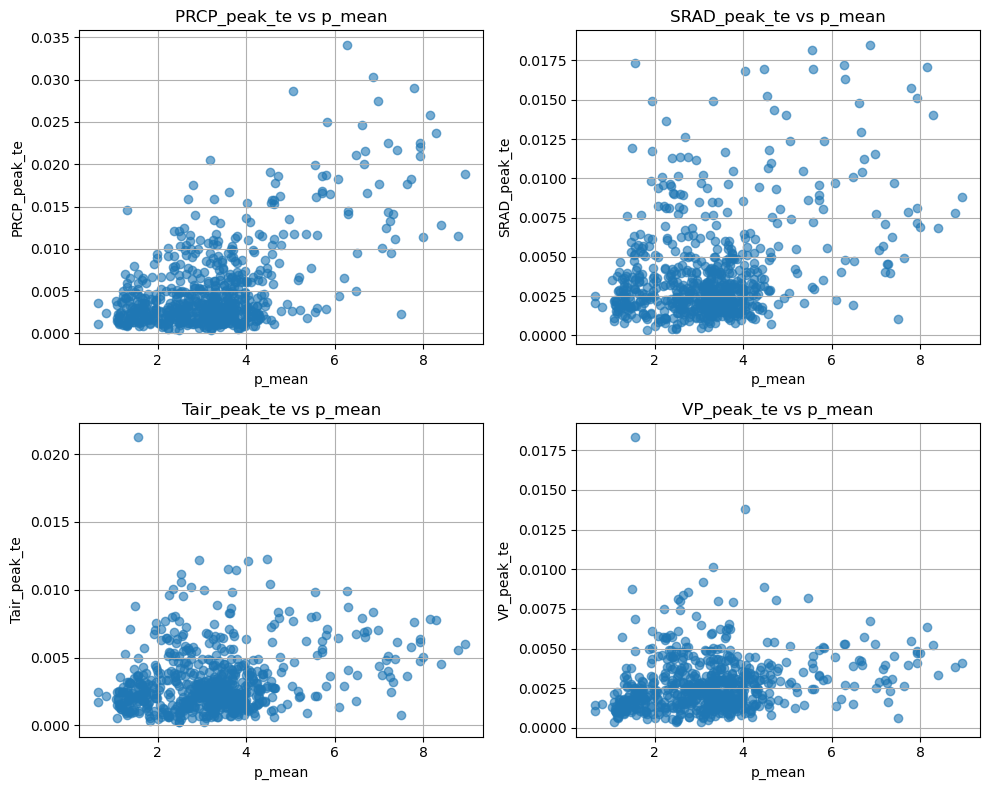

Saved: outputs\pdf\p_mean_vs_forcing_peak_TE_4panel.png


In [138]:
# choose one numeric attribute here
attr_name = "p_mean"   # change this to any numeric CAMELS attribute

# output folder
OUT_PDF = Path("outputs/pdf")
OUT_PDF.mkdir(parents=True, exist_ok=True)

# forcing-wise TE columns
forcing_te_cols = [
    "PRCP_peak_te",
    "SRAD_peak_te",
    "Tair_peak_te",
    "VP_peak_te"
]

# figure
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, te_col in zip(axes, forcing_te_cols):
    sub_df = te_attr_peak_df[[attr_name, te_col]].dropna()
    
    ax.scatter(sub_df[attr_name], sub_df[te_col], alpha=0.6)
    ax.set_xlabel(attr_name)
    ax.set_ylabel(te_col)
    ax.set_title(f"{te_col} vs {attr_name}")
    ax.grid(True)

plt.tight_layout()

# save
save_file = OUT_PDF / f"{attr_name}_vs_forcing_peak_TE_4panel.png"
plt.savefig(save_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_file)

## Plot forcing-wise peak TE against all numeric CAMELS attributes

In this step, I loop through all numeric CAMELS attributes and create one 4-panel scatter plot for each attribute, showing its relationship with PRCP, SRAD, Tair, and VP peak TE.

In [139]:
# Output folder
OUT_PDF = Path.cwd() / "outputs" / "pdf" / "forcing_peak_te_vs_numeric_attributes"
OUT_PDF.mkdir(parents=True, exist_ok=True)

# Forcing-wise TE columns
forcing_te_cols = [
    "PRCP_peak_te",
    "SRAD_peak_te",
    "Tair_peak_te",
    "VP_peak_te"
]

# Loop over all numeric attributes
for attr_name in numeric_attribute_cols:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()
    
    for ax, te_col in zip(axes, forcing_te_cols):
        sub_df = te_attr_peak_df[[attr_name, te_col]].dropna()
        
        ax.scatter(sub_df[attr_name], sub_df[te_col], alpha=0.6)
        ax.set_xlabel(attr_name)
        ax.set_ylabel(te_col)
        ax.set_title(f"{te_col} vs {attr_name}")
        ax.grid(True)
    
    plt.tight_layout()

    # Safe filename
    safe_attr_name = str(attr_name).replace("/", "_").replace("\\", "_").replace(" ", "_")
    save_file = OUT_PDF / f"{safe_attr_name}_vs_forcing_peak_te_4panel.png"
    save_file_long = "\\\\?\\" + str(save_file.resolve())

    plt.savefig(save_file_long, dpi=300, bbox_inches="tight")
    plt.close(fig)

print("Saved all figures in:", OUT_PDF)
print("Number of figures saved:", len(numeric_attribute_cols))

Saved all figures in: c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\pdf\forcing_peak_te_vs_numeric_attributes
Number of figures saved: 50


## Save forcing-wise peak TE vs all numeric attributes in one PDF

In this step, I create one multi-page PDF. Each page shows four scatter plots for one numeric CAMELS attribute against PRCP, SRAD, Tair, and VP peak TE.

In [140]:


# Output folder
OUT_PDF = Path.cwd() / "outputs" / "pdf"
OUT_PDF.mkdir(parents=True, exist_ok=True)

# PDF file
pdf_file = OUT_PDF / "all_numeric_attributes_vs_forcing_peak_te.pdf"

# Windows long-path fix
pdf_file_long = "\\\\?\\" + str(pdf_file.resolve())

# Forcing-wise TE columns
forcing_te_cols = [
    "PRCP_peak_te",
    "SRAD_peak_te",
    "Tair_peak_te",
    "VP_peak_te"
]

with PdfPages(pdf_file_long) as pdf:
    for attr_name in numeric_attribute_cols:
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        axes = axes.flatten()

        for ax, te_col in zip(axes, forcing_te_cols):
            sub_df = te_attr_peak_df[[attr_name, te_col]].dropna()

            ax.scatter(sub_df[attr_name], sub_df[te_col], alpha=0.6)
            ax.set_xlabel(attr_name)
            ax.set_ylabel(te_col)
            ax.set_title(f"{te_col} vs {attr_name}")
            ax.grid(True)

        fig.suptitle(f"Forcing-wise Peak TE vs {attr_name}", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.96])

        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("Saved PDF:", pdf_file)
print("Number of pages:", len(numeric_attribute_cols))

Saved PDF: c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\pdf\all_numeric_attributes_vs_forcing_peak_te.pdf
Number of pages: 50


A clear overall interpretation is that forcing-wise peak TE is not random across basins; it tends to be larger in wetter, more responsive basins and smaller in drier or more storage-limited basins. In the PDF, the strongest and clearest patterns are mostly seen for PRCP_peak_te, and to a slightly lesser degree for SRAD_peak_te, while Tair_peak_te and VP_peak_te usually show the same direction but with weaker scatter. For example, peak TE generally increases with variables such as p_mean, q_mean, runoff_ratio, slope_fdc, and baseflow_index, meaning that basins with more available water, larger streamflow, stronger runoff response, and more active flow pathways tend to transmit more information from meteorological forcings to streamflow. In contrast, peak TE generally decreases with aridity, pet_mean, high_prec_freq, low_prec_freq, low_prec_dur, and stream_elas, suggesting that in drier basins, or in basins where flow is more buffered and less directly connected to short-term forcing, the forcing-to-streamflow information transfer becomes weaker. The hydroclimatic and hydrologic attributes therefore appear much more informative than many geology-fraction attributes, which mostly show diffuse scatter and no strong trend. Overall, this suggests that high peak TE is most characteristic of humid, runoff-efficient, hydrologically responsive basins, whereas low peak TE is more common in arid, evapotranspiration-dominated, or storage-buffered basins. This is also consistent with our earlier basin-to-basin TE result that precipitation influence is strongest where rainfall can be translated into streamflow more directly, while energy-related forcings remain present but usually with more moderate and dispersed relationships across basins.


## Create top 10 numeric attributes for each forcing based on peak TE correlation

In this step, I rank all numeric CAMELS attributes for each forcing separately and extract the top 10 strongest relationships.

In [141]:
# Rank numeric attributes for each forcing using correlation with forcing-wise peak TE
forcing_rank_tables = []

for forcing in ["PRCP", "SRAD", "Tair", "VP"]:
    te_col = f"{forcing}_peak_te"
    rows = []

    for attr in numeric_attribute_cols:
        sub_df = te_attr_peak_df[[te_col, attr]].dropna()

        if len(sub_df) > 10:
            corr = sub_df[te_col].corr(sub_df[attr])
        else:
            corr = None

        rows.append({
            "forcing": forcing,
            "attribute": attr,
            "correlation": corr,
            "abs_correlation": abs(corr) if corr is not None else None
        })

    one_df = pd.DataFrame(rows).sort_values("abs_correlation", ascending=False).reset_index(drop=True)
    one_df["rank"] = one_df.index + 1
    forcing_rank_tables.append(one_df)

forcing_rank_df = pd.concat(forcing_rank_tables, ignore_index=True)

# Top 10 for each forcing
top10_forcing_rank_df = (
    forcing_rank_df[forcing_rank_df["rank"] <= 10]
    .copy()
    .sort_values(["forcing", "rank"])
    .reset_index(drop=True)
)

display(top10_forcing_rank_df)
print("shape:", top10_forcing_rank_df.shape)

,forcing,attribute,correlation,abs_correlation,rank
0,PRCP,q95,0.623732,0.623732,1
1,PRCP,q_mean,0.612236,0.612236,2
2,PRCP,p_mean,0.588174,0.588174,3
3,PRCP,runoff_ratio,0.440814,0.440814,4
4,PRCP,low_prec_freq,-0.404308,0.404308,5
5,PRCP,q5,0.398576,0.398576,6
6,PRCP,high_prec_freq,-0.367103,0.367103,7
7,PRCP,p_seasonality,-0.365119,0.365119,8
8,PRCP,hfd_mean,-0.360755,0.360755,9
9,PRCP,aridity,-0.337479,0.337479,10


shape: (40, 5)


## Compare one non-numeric CAMELS attribute across forcing-wise peak TE

In this step, I compare PRCP, SRAD, Tair, and VP peak TE across the categories of one non-numeric CAMELS attribute using boxplots.

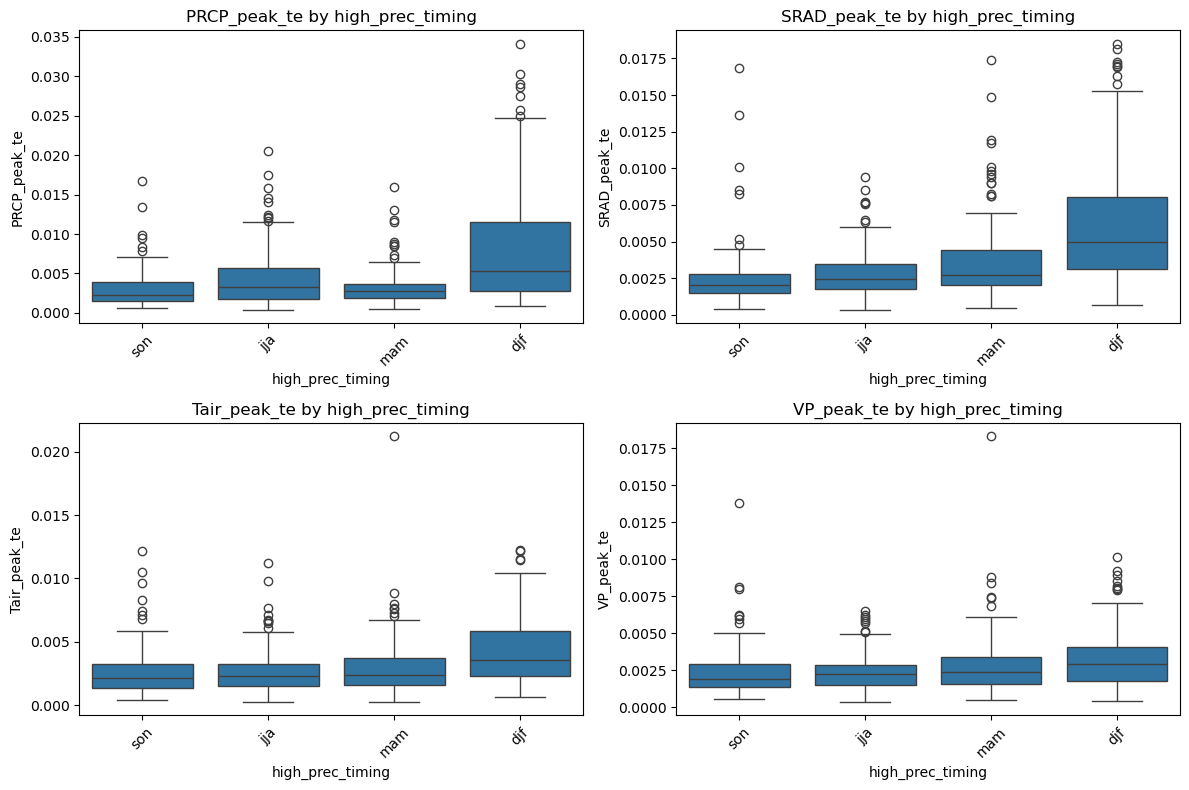

In [142]:
# choose one non-numeric attribute here
attr_name = "high_prec_timing"

forcing_te_cols = [
    "PRCP_peak_te",
    "SRAD_peak_te",
    "Tair_peak_te",
    "VP_peak_te"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, te_col in zip(axes, forcing_te_cols):
    sub_df = te_attr_peak_df[[attr_name, te_col]].dropna().copy()
    
    sns.boxplot(data=sub_df, x=attr_name, y=te_col, ax=ax)
    ax.set_title(f"{te_col} by {attr_name}")
    ax.set_xlabel(attr_name)
    ax.set_ylabel(te_col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The results show that forcing-wise peak TE varies with precipitation timing. For all forcings (PRCP, SRAD, Tair, and VP), the highest median TE values are generally observed in winter-dominated basins (DJF), while lower values are seen in other seasons such as SON and MAM. This suggests that basins where precipitation is concentrated in winter tend to have stronger information transfer from atmospheric forcings to streamflow. The pattern is most clear for PRCP and SRAD, while Tair and VP show similar but weaker differences. Overall, this indicates that seasonal precipitation timing plays an important role in controlling the strength of forcing–streamflow relationships across basins.

## Save forcing-wise peak TE results for all non-numeric attributes as both CSV and PDF

In this step, I save grouped summary statistics to one CSV file and save all boxplots to one multi-page PDF.

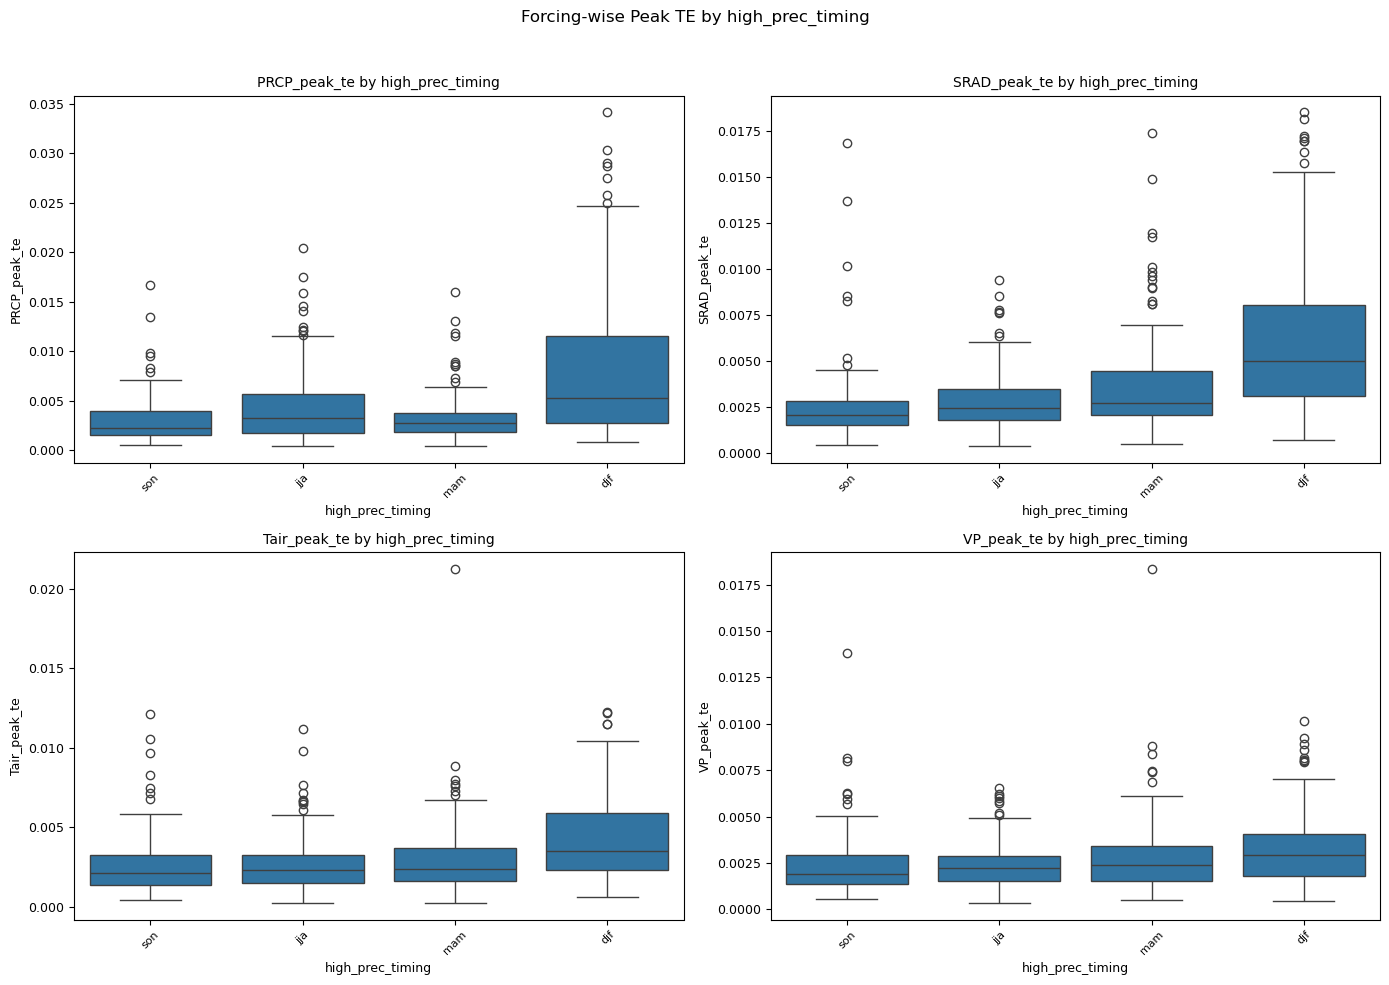

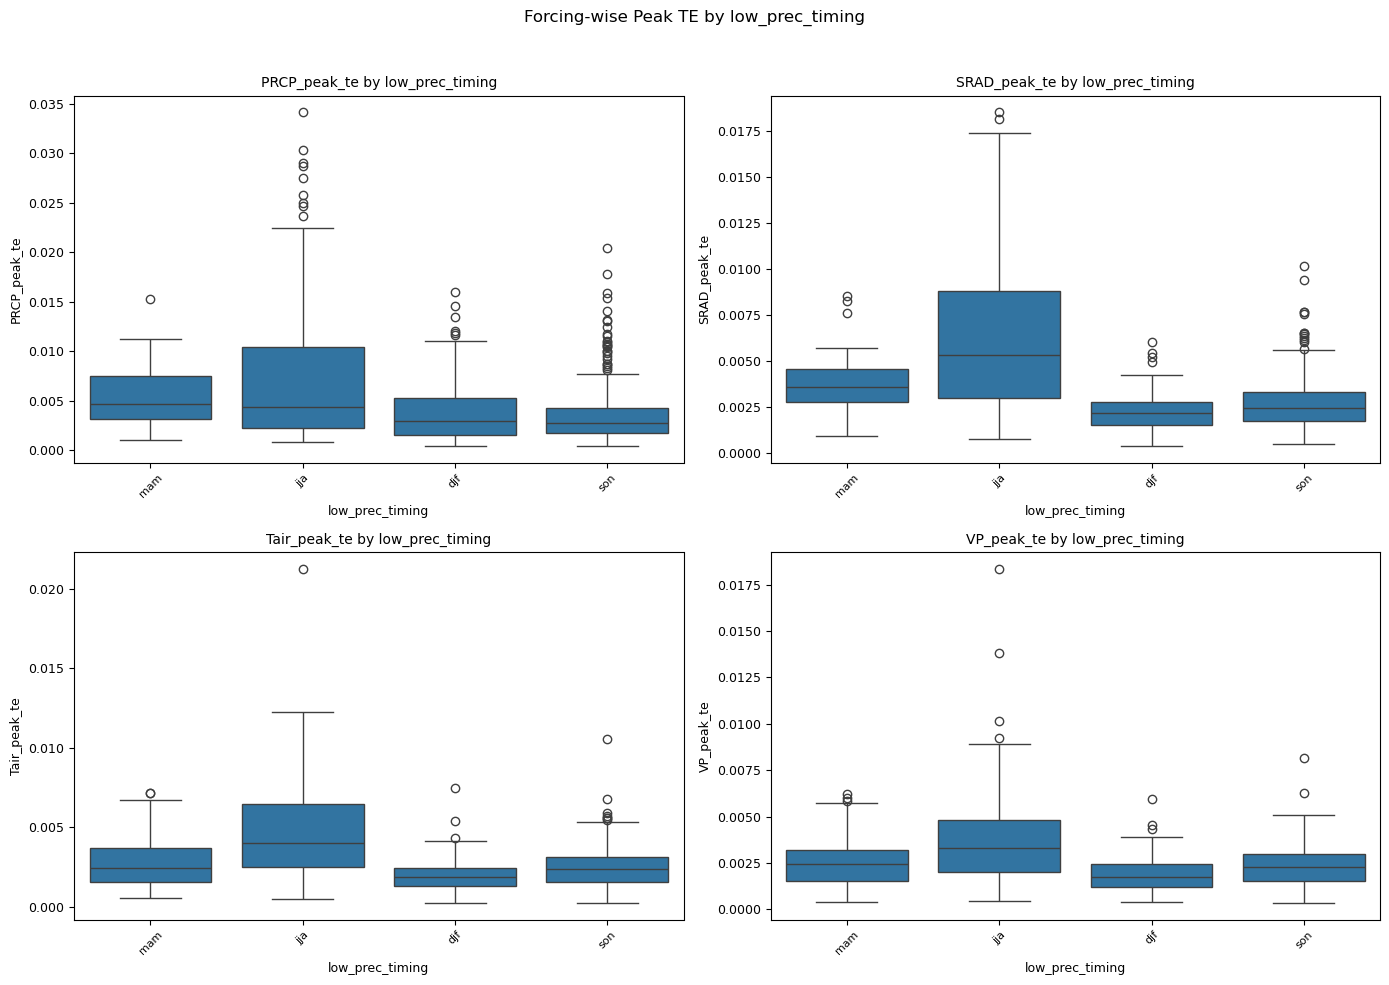

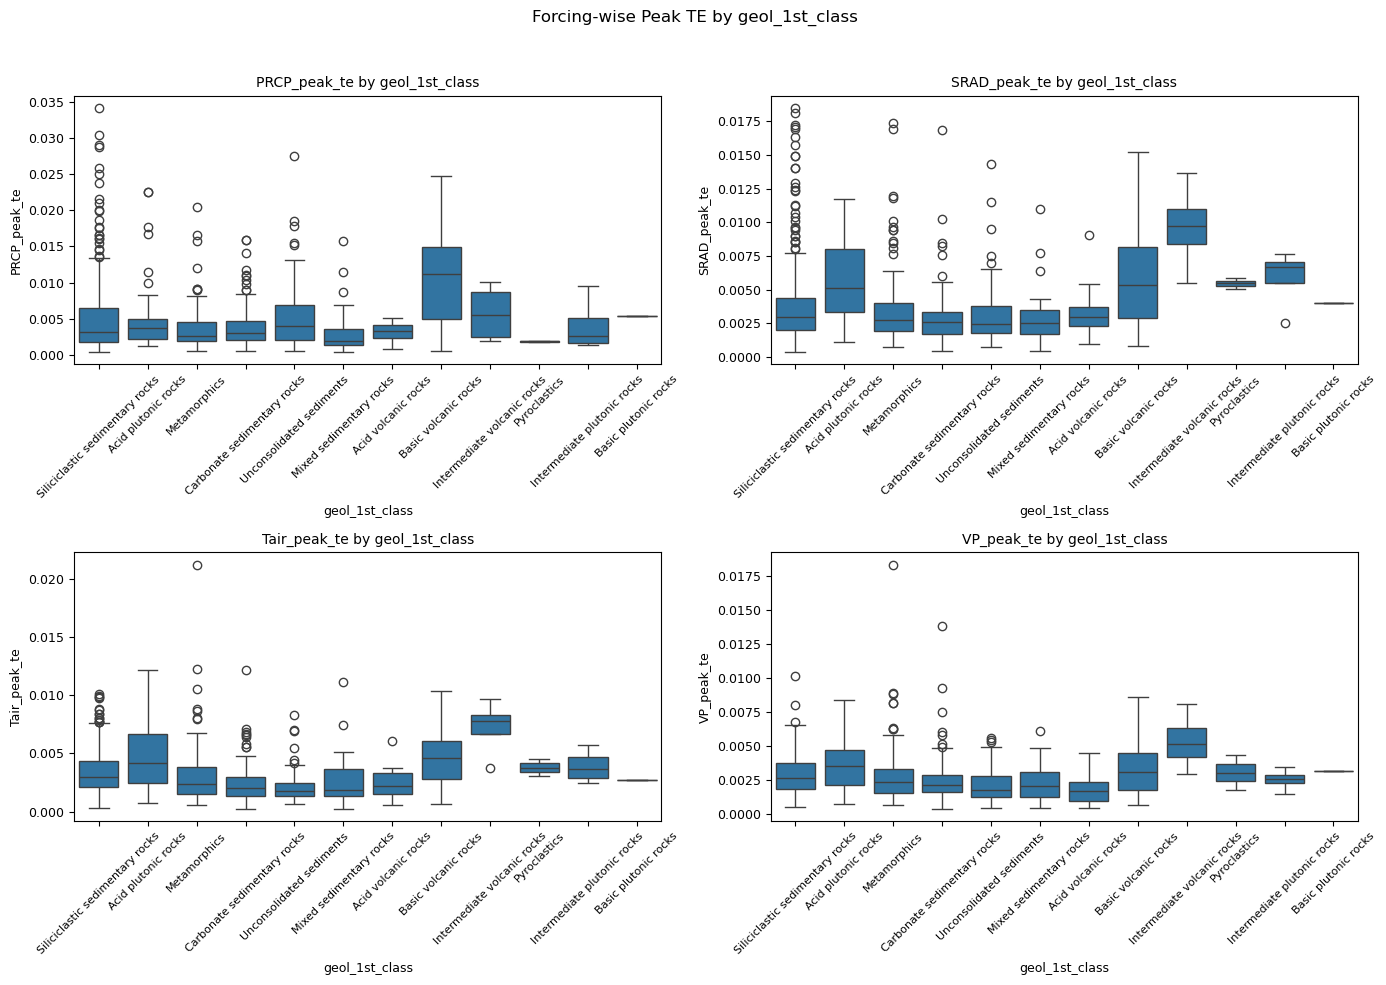

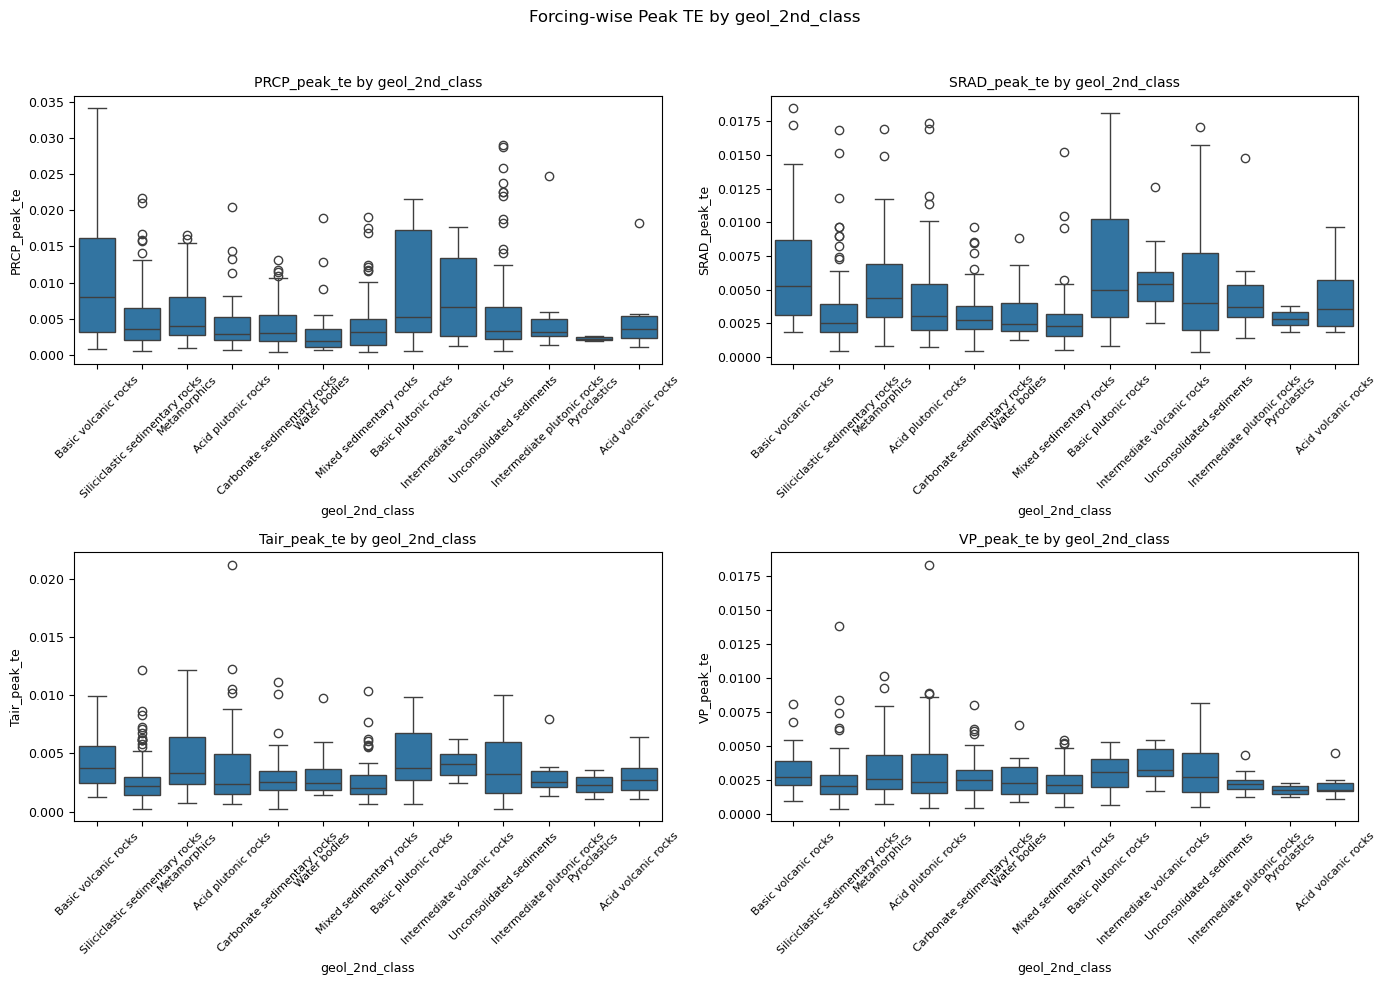

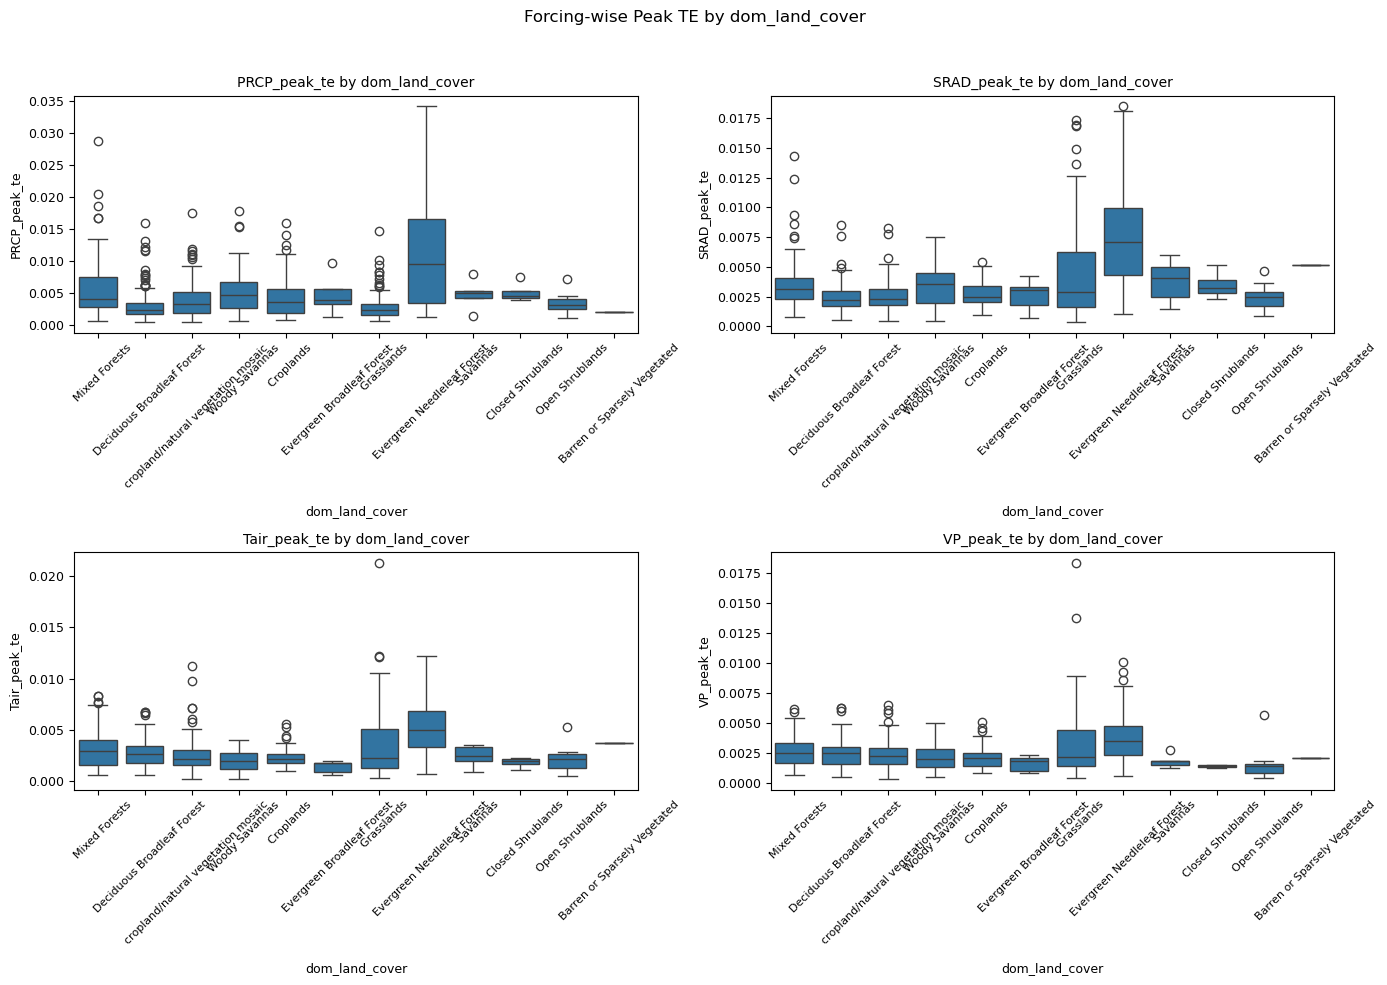

Saved CSV: c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\all_non_numeric_attributes_vs_forcing_peak_te_summary.csv
Saved PDF: c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\pdf\all_non_numeric_attributes_vs_forcing_peak_te.pdf
Number of PDF pages: 5
CSV shape: (180, 11)


In [143]:
# Output folders
OUT_SUMMARY = Path.cwd() / "outputs" / "summary_csv"
OUT_PDF = Path.cwd() / "outputs" / "pdf"
OUT_SUMMARY.mkdir(parents=True, exist_ok=True)
OUT_PDF.mkdir(parents=True, exist_ok=True)

# Forcing-wise TE columns
forcing_te_cols = [
    "PRCP_peak_te",
    "SRAD_peak_te",
    "Tair_peak_te",
    "VP_peak_te"
]
# 1) SAVE CSV SUMMARY
cat_te_summary_tables = []

for attr_name in non_numeric_attribute_cols:
    for te_col in forcing_te_cols:
        sub_df = te_attr_peak_df[[attr_name, te_col]].dropna().copy()

        summary = (
            sub_df
            .groupby(attr_name)[te_col]
            .agg(["count", "mean", "median", "std"])
            .reset_index()
            .sort_values("mean", ascending=False)
        )

        summary["attribute"] = attr_name
        summary["forcing_peak_te"] = te_col

        # reorder columns
        summary = summary[
            ["attribute", "forcing_peak_te", attr_name, "count", "mean", "median", "std"]
        ]

        cat_te_summary_tables.append(summary)

cat_te_summary_df = pd.concat(cat_te_summary_tables, ignore_index=True)

csv_file = OUT_SUMMARY / "all_non_numeric_attributes_vs_forcing_peak_te_summary.csv"
csv_file_long = "\\\\?\\" + str(csv_file.resolve())
cat_te_summary_df.to_csv(csv_file_long, index=False)

# 2) SAVE PDF PLOTS
pdf_file = OUT_PDF / "all_non_numeric_attributes_vs_forcing_peak_te.pdf"
pdf_file_long = "\\\\?\\" + str(pdf_file.resolve())

with PdfPages(pdf_file_long) as pdf:
    for attr_name in non_numeric_attribute_cols:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()

        for ax, te_col in zip(axes, forcing_te_cols):
            sub_df = te_attr_peak_df[[attr_name, te_col]].dropna().copy()

            sns.boxplot(data=sub_df, x=attr_name, y=te_col, ax=ax)
            ax.set_title(f"{te_col} by {attr_name}", fontsize=10)
            ax.set_xlabel(attr_name, fontsize=9)
            ax.set_ylabel(te_col, fontsize=9)
            ax.tick_params(axis="x", rotation=45, labelsize=8)
            ax.tick_params(axis="y", labelsize=9)

        fig.suptitle(f"Forcing-wise Peak TE by {attr_name}", fontsize=12)
        plt.tight_layout(rect=[0, 0, 1, 0.96])

        pdf.savefig(fig, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print("Saved CSV:", csv_file)
print("Saved PDF:", pdf_file)
print("Number of PDF pages:", len(non_numeric_attribute_cols))
print("CSV shape:", cat_te_summary_df.shape)

### Interpretation: Non-numeric CAMELS Attributes vs Peak TE

In this analysis, I examined how non-numeric (categorical) CAMELS attributes relate to peak transfer entropy (TE) across all four forcings (PRCP, SRAD, Tair, VP).

Overall, non-numeric attributes show some influence on peak TE, but their effect is weaker and more variable compared to numeric attributes.

For precipitation timing (high_prec_timing and low_prec_timing), peak TE tends to be higher in DJF (winter) across all forcings, especially for PRCP and SRAD. Other seasons (SON, JJA, MAM) show lower and more similar TE values. This suggests that forcing–streamflow information transfer is stronger when precipitation occurs during wetter or snow-influenced seasons.

For geology (geol_1st_class and geol_2nd_class), peak TE varies across different rock types, but no single category clearly dominates. Some rock types show slightly higher variability in TE, indicating that geology influences TE indirectly through storage, permeability, and subsurface flow processes rather than acting as a primary control.

For land cover (dom_land_cover), forested basins (e.g., mixed and evergreen forests) tend to show moderate to higher TE, while barren or shrub-dominated areas generally show lower TE. This indicates that vegetation plays a role in regulating how precipitation is converted into streamflow through processes such as interception and evapotranspiration.

In summary, non-numeric attributes help explain differences in hydrologic behavior between basin groups, but they do not show strong, continuous relationships with TE like numeric attributes. Their influence is more indirect and process-based.

## Numeric attributes vs forcing-wise peak lag

In this step, I compute Pearson and Spearman correlations between each forcing-wise peak lag and all numeric CAMELS attributes, then save one combined CSV summary.

In [144]:
# Forcing-wise lag columns
lag_cols = ["PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag"]

# Columns to exclude from numeric attribute analysis
exclude_cols = {
    "gauge_id", "huc_02",
    "peak_lag", "peak_TE",
    "PRCP", "SRAD", "Tair", "VP",
    "PRCP_peak_te", "SRAD_peak_te", "Tair_peak_te", "VP_peak_te",
    "PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag", "gauge_lat", "gauge_lon"
}

# Keep only numeric CAMELS attributes
all_numeric_cols = te_attr_peak_df.select_dtypes(include="number").columns.tolist()
numeric_attr_cols = [c for c in all_numeric_cols if c not in exclude_cols]

# Correlation table
rows = []

for lag_col in lag_cols:
    forcing = lag_col.replace("_peak_lag", "")
    
    for attr in numeric_attr_cols:
        sub = te_attr_peak_df[[lag_col, attr]].dropna().copy()
        
        if len(sub) >= 3 and sub[lag_col].nunique() > 1 and sub[attr].nunique() > 1:
            pearson_r = sub[lag_col].corr(sub[attr], method="pearson")
            spearman_r = sub[lag_col].corr(sub[attr], method="spearman")
        else:
            pearson_r = float("nan")
            spearman_r = float("nan")
        
        rows.append({
            "forcing": forcing,
            "lag_column": lag_col,
            "attribute": attr,
            "n": len(sub),
            "pearson_r": pearson_r,
            "spearman_r": spearman_r,
            "abs_pearson_r": abs(pearson_r) if pd.notna(pearson_r) else float("nan"),
            "abs_spearman_r": abs(spearman_r) if pd.notna(spearman_r) else float("nan")
        })

lag_corr_df = pd.DataFrame(rows)

# Rank within each forcing by absolute Spearman correlation
lag_corr_df["rank_within_forcing"] = (
    lag_corr_df.groupby("forcing")["abs_spearman_r"]
    .rank(method="dense", ascending=False)
)

# Sort and save
lag_corr_df = lag_corr_df.sort_values(
    ["forcing", "abs_spearman_r", "abs_pearson_r"],
    ascending=[True, False, False]
).reset_index(drop=True)

lag_corr_file = OUT_SUMMARY / "numeric_attributes_vs_peak_lag.csv"
lag_corr_df.to_csv(lag_corr_file, index=False)

print("numeric_attr_cols:", len(numeric_attr_cols))
print("lag_corr_df shape:", lag_corr_df.shape)
print(lag_corr_file)

display(lag_corr_df.groupby("forcing").head(10))

numeric_attr_cols: 50
lag_corr_df shape: (200, 9)
c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\numeric_attributes_vs_peak_lag.csv


,forcing,lag_column,attribute,n,pearson_r,spearman_r,abs_pearson_r,abs_spearman_r,rank_within_forcing
0,PRCP,PRCP_peak_lag,hfd_mean,670,0.234095,0.232167,0.234095,0.232167,1.0
1,PRCP,PRCP_peak_lag,p_mean,671,-0.213435,-0.219156,0.213435,0.219156,2.0
2,PRCP,PRCP_peak_lag,high_q_dur,670,0.173181,0.218703,0.173181,0.218703,3.0
3,PRCP,PRCP_peak_lag,aridity,671,0.257689,0.215411,0.257689,0.215411,4.0
4,PRCP,PRCP_peak_lag,root_depth_50,647,-0.213658,-0.207729,0.213658,0.207729,5.0
5,PRCP,PRCP_peak_lag,frac_snow,671,0.283207,0.204399,0.283207,0.204399,6.0
6,PRCP,PRCP_peak_lag,gvf_max,671,-0.197172,-0.199466,0.197172,0.199466,7.0
7,PRCP,PRCP_peak_lag,elev_mean,671,0.340826,0.183446,0.340826,0.183446,8.0
8,PRCP,PRCP_peak_lag,lai_max,671,-0.182430,-0.171397,0.182430,0.171397,9.0
9,PRCP,PRCP_peak_lag,root_depth_99,647,-0.131808,-0.153672,0.131808,0.153672,10.0


### Peak lag–attribute correlation summary

This table shows the relationship between forcing-wise **peak lag** and numeric CAMELS attributes across basins.

- **forcing**: atmospheric forcing variable (PRCP, SRAD, Tair, VP)
- **lag_column**: peak-lag column used for that forcing
- **attribute**: numeric CAMELS attribute being compared with peak lag
- **n**: number of basins used after removing missing values
- **pearson_r**: linear correlation between peak lag and the attribute
- **spearman_r**: rank-based correlation between peak lag and the attribute
- **abs_pearson_r**: absolute value of Pearson correlation
- **abs_spearman_r**: absolute value of Spearman correlation
- **rank_within_forcing**: attribute rank within each forcing based on absolute Spearman correlation

A positive correlation means basins with larger attribute values tend to have **longer peak lag**, while a negative correlation means they tend to have **shorter peak lag**.

The peak-lag correlations are generally weak to moderate, which is expected because lag is a noisier response metric than peak TE. Still, some meaningful patterns appear. For PRCP, longer peak lag tends to occur in basins with larger hfd_mean, high_prec_dur, and aridity, while shorter lag is associated with higher p_mean and root_depth_50. For SRAD, the strongest relationships are with p_seasonality, gvf_diff, and pet_mean, suggesting seasonal climate and vegetation variability influence energy-related lag timing. For Tair, longer lag is strongly linked to frac_snow, with additional effects from location and elevation, which is physically consistent with delayed snowmelt response. For VP, longer lag is related most strongly to longitude, root_depth_50, and hfd_mean, while some precipitation-duration variables show shorter lag. Overall, these results suggest that peak lag is controlled more by basin storage, snow influence, seasonality, and climate regime than by a single dominant attribute.

## Plot numeric attributes against forcing-wise peak lag

In this step, I create one multi-page PDF. Each page shows one numeric CAMELS attribute against the peak lag of PRCP, SRAD, Tair, and VP.

In [145]:
# Output folder
PROJECT_DIR = Path.cwd()
OUT_PDF = PROJECT_DIR / "outputs" / "pdf"
OUT_PDF.mkdir(parents=True, exist_ok=True)

# Forcing-wise lag columns
lag_plot_cols = ["PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag"]

# PDF file
lag_pdf_file = OUT_PDF / "all_numeric_attributes_vs_forcing_peak_lag.pdf"

with PdfPages(lag_pdf_file) as pdf:
    for attr in numeric_attr_cols:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()

        for ax, lag_col in zip(axes, lag_plot_cols):
            forcing = lag_col.replace("_peak_lag", "")
            sub = te_attr_peak_df[[attr, lag_col]].dropna().copy()

            ax.scatter(sub[attr], sub[lag_col], alpha=0.5, s=18)
            ax.set_title(f"{lag_col} vs {attr}", fontsize=11)
            ax.set_xlabel(attr, fontsize=9)
            ax.set_ylabel(lag_col, fontsize=9)
            ax.tick_params(axis="both", labelsize=8)
            ax.grid(True, alpha=0.3)

        fig.suptitle(f"Forcing-wise Peak Lag vs {attr}", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(lag_pdf_file)

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\pdf\all_numeric_attributes_vs_forcing_peak_lag.pdf


The scatter plots show that peak lag has much more spread and noise than peak TE, so the relationships are visible but not very tight. In general, PRCP peak lag is still concentrated at very short lags for many basins, while Tair and VP peak lags are more widely distributed across the full 1–30 day range. The clearest visual patterns are that snow-related and seasonal/climate variables such as frac_snow, p_seasonality, aridity, and some flow/storage indicators tend to be associated with longer lags, especially for Tair, SRAD, and VP. By contrast, many basins still show very short lags (around 1–3 days), especially for PRCP, meaning fast runoff response remains common. Overall, these figures support the idea that lag timing is controlled more by snow influence, basin storage, seasonality, and hydroclimatic regime than by one single attribute, and the visual patterns are consistent with the weak-to-moderate correlations you computed earlier.

## Non-numeric attributes vs forcing-wise peak lag

In this step, I compare forcing-wise peak lag across the non-numeric CAMELS attributes using boxplots and save one PDF and one summary CSV.

In [146]:
# Non-numeric attributes
cat_attrs = [
    "high_prec_timing",
    "low_prec_timing",
    "geol_1st_class",
    "geol_2nd_class",
    "dom_land_cover"
]

# Forcing-wise lag columns
lag_cols = ["PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag"]

# Output files
cat_lag_pdf = OUT_PDF / "all_non_numeric_attributes_vs_forcing_peak_lag.pdf"
cat_lag_csv = OUT_SUMMARY / "categorical_attributes_vs_peak_lag.csv"

summary_rows = []

with PdfPages(cat_lag_pdf) as pdf:
    for cat_attr in cat_attrs:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()

        for ax, lag_col in zip(axes, lag_cols):
            forcing = lag_col.replace("_peak_lag", "")
            sub = te_attr_peak_df[[cat_attr, lag_col]].dropna().copy()

            grouped = sub.groupby(cat_attr)[lag_col]
            categories = [c for c in grouped.mean().sort_values().index]
            data = [sub.loc[sub[cat_attr] == c, lag_col].values for c in categories]

            ax.boxplot(data, tick_labels=categories)
            ax.set_title(f"{lag_col} by {cat_attr}", fontsize=11)
            ax.set_xlabel(cat_attr, fontsize=9)
            ax.set_ylabel(lag_col, fontsize=9)
            ax.tick_params(axis="x", labelrotation=45, labelsize=8)
            ax.tick_params(axis="y", labelsize=8)
            ax.grid(True, alpha=0.3)

            # Summary rows
            stats_df = grouped.agg(["count", "mean", "median", "std"]).reset_index()
            stats_df["forcing"] = forcing
            stats_df["lag_column"] = lag_col
            stats_df["category_attribute"] = cat_attr
            stats_df = stats_df.rename(columns={cat_attr: "category"})
            summary_rows.append(stats_df)

        fig.suptitle(f"Forcing-wise Peak Lag by {cat_attr}", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

cat_lag_summary_df = pd.concat(summary_rows, ignore_index=True)
cat_lag_summary_df.to_csv(cat_lag_csv, index=False)

print(cat_lag_pdf)
print(cat_lag_csv)
display(cat_lag_summary_df.head())

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\pdf\all_non_numeric_attributes_vs_forcing_peak_lag.pdf
c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\categorical_attributes_vs_peak_lag.csv


,category,count,mean,median,std,forcing,lag_column,category_attribute
0,djf,214,2.042056,1.0,4.440859,PRCP,PRCP_peak_lag,high_prec_timing
1,jja,236,2.343220,1.0,4.321741,PRCP,PRCP_peak_lag,high_prec_timing
2,mam,124,3.822581,1.0,6.687020,PRCP,PRCP_peak_lag,high_prec_timing
3,son,97,2.216495,1.0,3.956079,PRCP,PRCP_peak_lag,high_prec_timing
4,djf,214,2.799065,1.0,5.430033,SRAD,SRAD_peak_lag,high_prec_timing


### Peak lag by non-numeric basin attributes

These boxplots compare forcing-wise **peak lag** across non-numeric CAMELS attributes.

- **high_prec_timing**: season of highest precipitation
- **low_prec_timing**: season of lowest precipitation
- **geol_1st_class**: primary geology class
- **geol_2nd_class**: secondary geology class
- **dom_land_cover**: dominant land-cover type

Each boxplot shows how the peak lag of **PRCP, SRAD, Tair, and VP** changes among categories. Higher median values indicate **longer response lag**, while lower median values indicate **shorter response lag**.

The categorical plots show that PRCP peak lag remains short in most groups, with many basins still concentrated near lag 1, so category effects on rainfall-response timing are weaker. In contrast, SRAD, Tair, and VP peak lags vary much more across categories, especially for seasonal timing, geology, and land cover. The season-based plots on pages 1–2 suggest that basins with different precipitation timing can have noticeably different median lags, especially for Tair and VP, which supports the idea that climate seasonality affects delayed response. The geology plots on pages 3–4 show broad spread across rock classes, meaning geology likely influences lag indirectly through storage, permeability, and snowmelt pathways rather than in one simple pattern. The land-cover plots on page 5 also show differences, with some vegetation classes tending toward longer Tair and VP lags, suggesting that vegetation and evapotranspiration processes help control delayed hydrologic response. Overall, these figures indicate that categorical basin characteristics matter more for energy-related lag timing than for direct PRCP lag timing.

## Create forcing ranking for each basin

In this step, I rank the four forcings within each basin using forcing-wise peak TE. I also keep the corresponding peak lag for each rank and save one final basin-wise ranking table.

In [147]:
# Forcing order
forcings = ["PRCP", "SRAD", "Tair", "VP"]

# Build basin-wise ranking table
ranking_rows = []

for _, row in peak_te_summary.iterrows():
    gauge_id = row["gauge_id"]
    
    basin_list = []
    for forcing in forcings:
        basin_list.append({
            "forcing": forcing,
            "peak_te": row[f"{forcing}_peak_te"],
            "peak_lag": row[f"{forcing}_peak_lag"]
        })
    
    # Rank by peak TE (largest first)
    basin_list = sorted(basin_list, key=lambda x: x["peak_te"], reverse=True)
    
    out_row = {"gauge_id": gauge_id}
    
    for i, item in enumerate(basin_list, start=1):
        out_row[f"rank_{i}_forcing"] = item["forcing"]
        out_row[f"rank_{i}_peak_te"] = item["peak_te"]
        out_row[f"rank_{i}_peak_lag"] = item["peak_lag"]
    
    ranking_rows.append(out_row)

forcing_rank_df = pd.DataFrame(ranking_rows)

# Save
rank_file = OUT_SUMMARY / "forcing_ranking_per_basin_671basins.csv"
forcing_rank_df.to_csv(rank_file, index=False)

print("forcing_rank_df shape:", forcing_rank_df.shape)
print(rank_file)
display(forcing_rank_df.head())

forcing_rank_df shape: (671, 13)
c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\forcing_ranking_per_basin_671basins.csv


,gauge_id,rank_1_forcing,rank_1_peak_te,rank_1_peak_lag,rank_2_forcing,rank_2_peak_te,rank_2_peak_lag,rank_3_forcing,rank_3_peak_te,rank_3_peak_lag,rank_4_forcing,rank_4_peak_te,rank_4_peak_lag
0,01013500,Tair,0.004888,14,SRAD,0.003063,13,PRCP,0.002761,1,VP,0.002685,22
1,01022500,PRCP,0.016681,1,Tair,0.008300,1,VP,0.006192,1,SRAD,0.004775,1
2,01030500,PRCP,0.013428,1,Tair,0.007460,2,VP,0.005949,2,SRAD,0.004072,5
3,01031500,PRCP,0.003859,1,VP,0.001597,1,SRAD,0.001481,1,Tair,0.001351,6
4,01047000,PRCP,0.002277,1,Tair,0.001541,17,SRAD,0.001389,3,VP,0.001330,1


## Summarize forcing ranks across all basins

In this step, I count how many basins assign each forcing to rank 1, rank 2, rank 3, and rank 4, and save one combined summary CSV.

In [148]:
# Count how many times each forcing appears in each rank
rank_summary = pd.DataFrame(index=["PRCP", "SRAD", "Tair", "VP"])

for i in range(1, 5):
    col = f"rank_{i}_forcing"
    counts = forcing_rank_df[col].value_counts()
    rank_summary[f"rank_{i}_count"] = rank_summary.index.map(counts).fillna(0).astype(int)

# Total check
rank_summary["total_across_ranks"] = rank_summary.sum(axis=1)

# Save
rank_summary = rank_summary.reset_index().rename(columns={"index": "forcing"})
rank_summary_file = OUT_SUMMARY / "forcing_rank_summary_counts_671basins.csv"
rank_summary.to_csv(rank_summary_file, index=False)

print(rank_summary_file)
display(rank_summary)

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\forcing_rank_summary_counts_671basins.csv


,forcing,rank_1_count,rank_2_count,rank_3_count,rank_4_count,total_across_ranks
0,PRCP,388,53,60,170,671
1,SRAD,157,309,143,62,671
2,Tair,95,165,235,176,671
3,VP,31,144,233,263,671


## Plot forcing rank counts across all basins

In this step, I make a simple bar plot showing how many basins assign each forcing to rank 1, rank 2, rank 3, and rank 4.

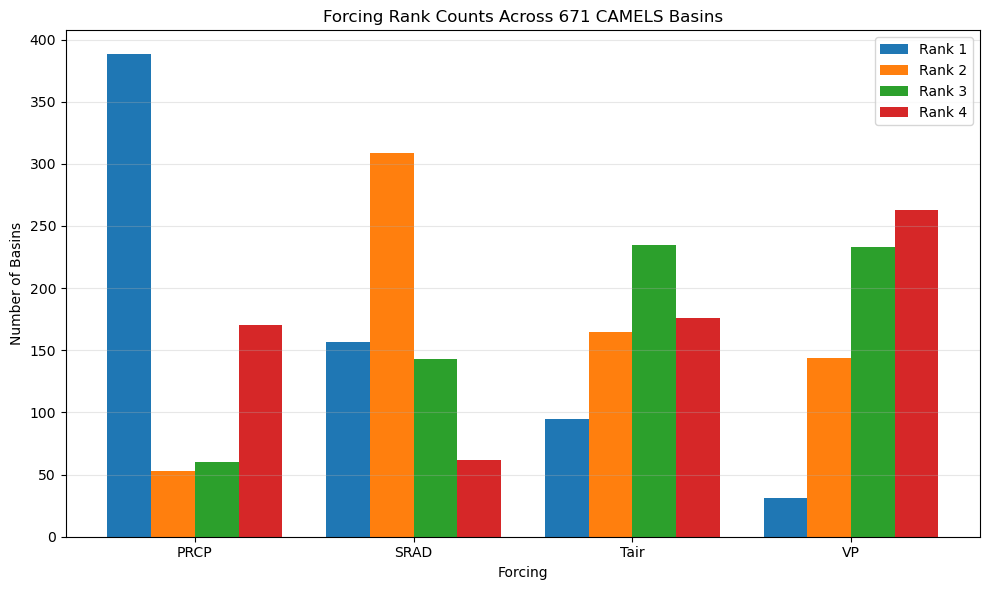

In [149]:
# Prepare plot data
plot_df = rank_summary.copy()

forcings = plot_df["forcing"].tolist()
x = np.arange(len(forcings))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - 1.5*width, plot_df["rank_1_count"], width, label="Rank 1")
ax.bar(x - 0.5*width, plot_df["rank_2_count"], width, label="Rank 2")
ax.bar(x + 0.5*width, plot_df["rank_3_count"], width, label="Rank 3")
ax.bar(x + 1.5*width, plot_df["rank_4_count"], width, label="Rank 4")

ax.set_xlabel("Forcing")
ax.set_ylabel("Number of Basins")
ax.set_title("Forcing Rank Counts Across 671 CAMELS Basins")
ax.set_xticks(x)
ax.set_xticklabels(forcings)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The bar plot clearly shows that PRCP is the dominant rank-1 forcing across the 671 CAMELS basins, which means precipitation most often gives the strongest peak TE signal to streamflow. SRAD is most frequently rank 2, suggesting it is often an important secondary control rather than the main one. Tair appears mostly in ranks 2 and 3, showing a moderate but widespread role across basins. VP is rarely rank 1 and is most commonly rank 4, so it tends to be the weakest of the four forcings in peak TE ranking. Overall, the ranking pattern indicates that precipitation is usually the strongest direct driver, while the energy-related variables provide broader secondary influence across many basins.

## Create Budyko-based basin classes

In this step, I classify each basin into Budyko-style hydroclimatic classes using the existing CAMELS aridity index. I keep one row per basin and save the classification table for later TE and lag comparisons.

In [150]:
# Keep one row per basin
budyko_df = te_attr_peak_df.drop_duplicates(subset="gauge_id").copy()

# Budyko-style classification using aridity
# aridity <= 1  -> energy-limited
# aridity > 1   -> water-limited
budyko_df["budyko_class"] = np.where(
    budyko_df["aridity"] <= 1,
    "energy_limited",
    "water_limited"
)

# Keep useful columns
keep_cols = [
    "gauge_id",
    "gauge_name",
    "gauge_lat",
    "gauge_lon",
    "aridity",
    "runoff_ratio",
    "p_mean",
    "pet_mean",
    "frac_snow",
    "dominant_forcing",
    "peak_lag",
    "peak_TE",
    "PRCP_peak_te", "SRAD_peak_te", "Tair_peak_te", "VP_peak_te",
    "PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag",
    "budyko_class"
]

budyko_df = budyko_df[keep_cols].copy()

# Save
budyko_file = OUT_SUMMARY / "budyko_classification_671basins.csv"
budyko_df.to_csv(budyko_file, index=False)

print("budyko_df shape:", budyko_df.shape)
print(budyko_file)
display(budyko_df[["gauge_id", "aridity", "budyko_class"]].head())
print()
print(budyko_df["budyko_class"].value_counts())

budyko_df shape: (671, 21)
c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\budyko_classification_671basins.csv


,gauge_id,aridity,budyko_class
0,01013500,0.630559,energy_limited
1,01022500,0.587356,energy_limited
2,01030500,0.624111,energy_limited
3,01031500,0.587950,energy_limited
4,01047000,0.628929,energy_limited



budyko_class
energy_limited    436
water_limited     235
Name: count, dtype: int64


## Summarize Budyko basin classes

In this step, I count how many basins fall into each Budyko class and make a simple bar plot.

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\budyko_class_summary_counts_671basins.csv


,budyko_class,count
0,energy_limited,436
1,water_limited,235


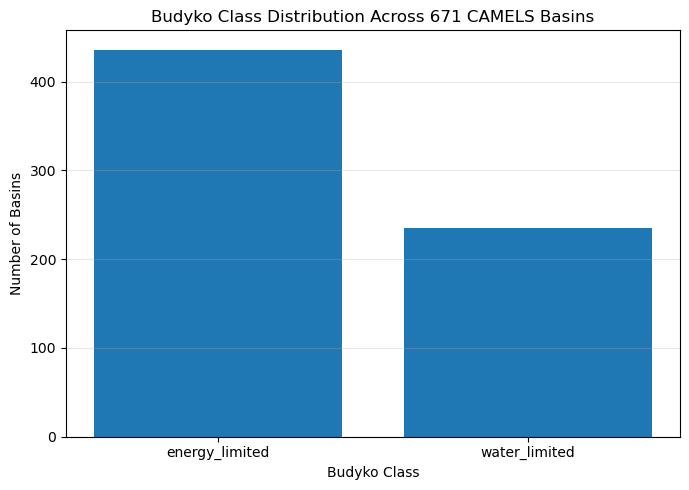

In [151]:
# Count Budyko classes
budyko_summary = (
    budyko_df["budyko_class"]
    .value_counts()
    .rename_axis("budyko_class")
    .reset_index(name="count")
)

# Save
budyko_summary_file = OUT_SUMMARY / "budyko_class_summary_counts_671basins.csv"
budyko_summary.to_csv(budyko_summary_file, index=False)

print(budyko_summary_file)
display(budyko_summary)

# Bar plot
plt.figure(figsize=(7, 5))
plt.bar(budyko_summary["budyko_class"], budyko_summary["count"])
plt.xlabel("Budyko Class")
plt.ylabel("Number of Basins")
plt.title("Budyko Class Distribution Across 671 CAMELS Basins")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The Budyko classification shows that most CAMELS basins in this dataset are energy-limited rather than water-limited. This means that for a larger number of basins, water availability is relatively sufficient compared to atmospheric demand, while a smaller group of basins is more strongly constrained by dryness and evaporative demand. This classification now gives a physically meaningful framework to compare TE strength, lag behavior, and dominant forcing patterns across hydroclimatic regimes.

## Compare dominant forcing by Budyko class

In this step, I count the dominant forcing within each Budyko class and plot the distribution.

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\dominant_forcing_by_budyko_class_671basins.csv


dominant_forcing,PRCP,SRAD,Tair,VP
budyko_class,,,,
energy_limited,269,65,83,19
water_limited,119,92,12,12


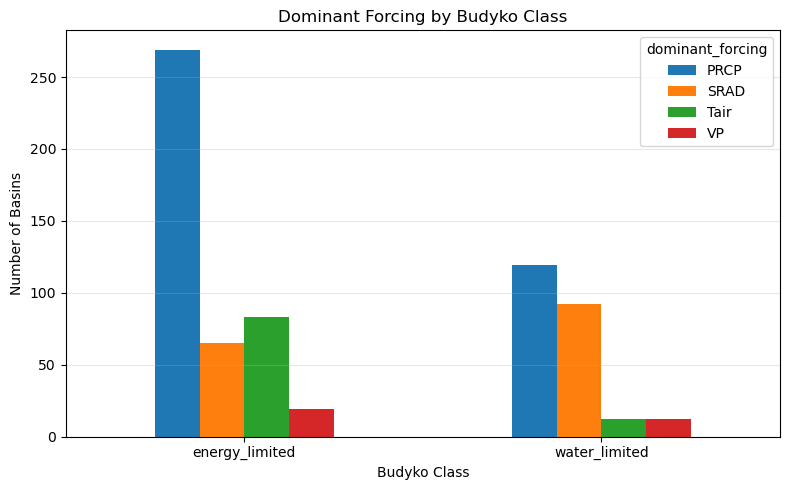

In [152]:
# Count dominant forcing within each Budyko class
budyko_force_counts = (
    budyko_df.groupby(["budyko_class", "dominant_forcing"])
    .size()
    .reset_index(name="count")
)

# Pivot for easier plotting
budyko_force_pivot = (
    budyko_force_counts
    .pivot(index="budyko_class", columns="dominant_forcing", values="count")
    .fillna(0)
    .astype(int)
)

# Keep forcing order
forcing_order = ["PRCP", "SRAD", "Tair", "VP"]
budyko_force_pivot = budyko_force_pivot.reindex(columns=forcing_order, fill_value=0)

# Save
budyko_force_file = OUT_SUMMARY / "dominant_forcing_by_budyko_class_671basins.csv"
budyko_force_pivot.to_csv(budyko_force_file)

print(budyko_force_file)
display(budyko_force_pivot)

# Plot
ax = budyko_force_pivot.plot(kind="bar", figsize=(8, 5))
ax.set_xlabel("Budyko Class")
ax.set_ylabel("Number of Basins")
ax.set_title("Dominant Forcing by Budyko Class")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The plot shows a clear difference in dominant forcing between the two Budyko classes. In energy-limited basins, PRCP is still the most common dominant forcing, but Tair also appears relatively often, which suggests that temperature and related energy controls matter more in wetter basins. In water-limited basins, PRCP remains dominant, but SRAD becomes much more prominent, while Tair becomes much less common. VP is rare in both classes. Overall, this suggests that the hydroclimatic regime changes the balance between rainfall-driven and energy-driven controls on streamflow TE.

## Compare forcing-wise peak TE by Budyko class

In this step, I compare the peak TE of PRCP, SRAD, Tair, and VP between energy-limited and water-limited basins using boxplots and save a summary CSV.

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\peak_te_by_budyko_class_671basins.csv


,budyko_class,count,mean,median,std,forcing,te_column
0,energy_limited,436,0.006222,0.003759,0.005874,PRCP,PRCP_peak_te
1,water_limited,235,0.003275,0.002540,0.002257,PRCP,PRCP_peak_te
2,energy_limited,436,0.004111,0.002972,0.003375,SRAD,SRAD_peak_te
3,water_limited,235,0.003688,0.002804,0.002838,SRAD,SRAD_peak_te
4,energy_limited,436,0.003380,0.002775,0.002202,Tair,Tair_peak_te
5,water_limited,235,0.002846,0.002127,0.002401,Tair,Tair_peak_te
6,energy_limited,436,0.002884,0.002657,0.001594,VP,VP_peak_te
7,water_limited,235,0.002472,0.001852,0.001947,VP,VP_peak_te


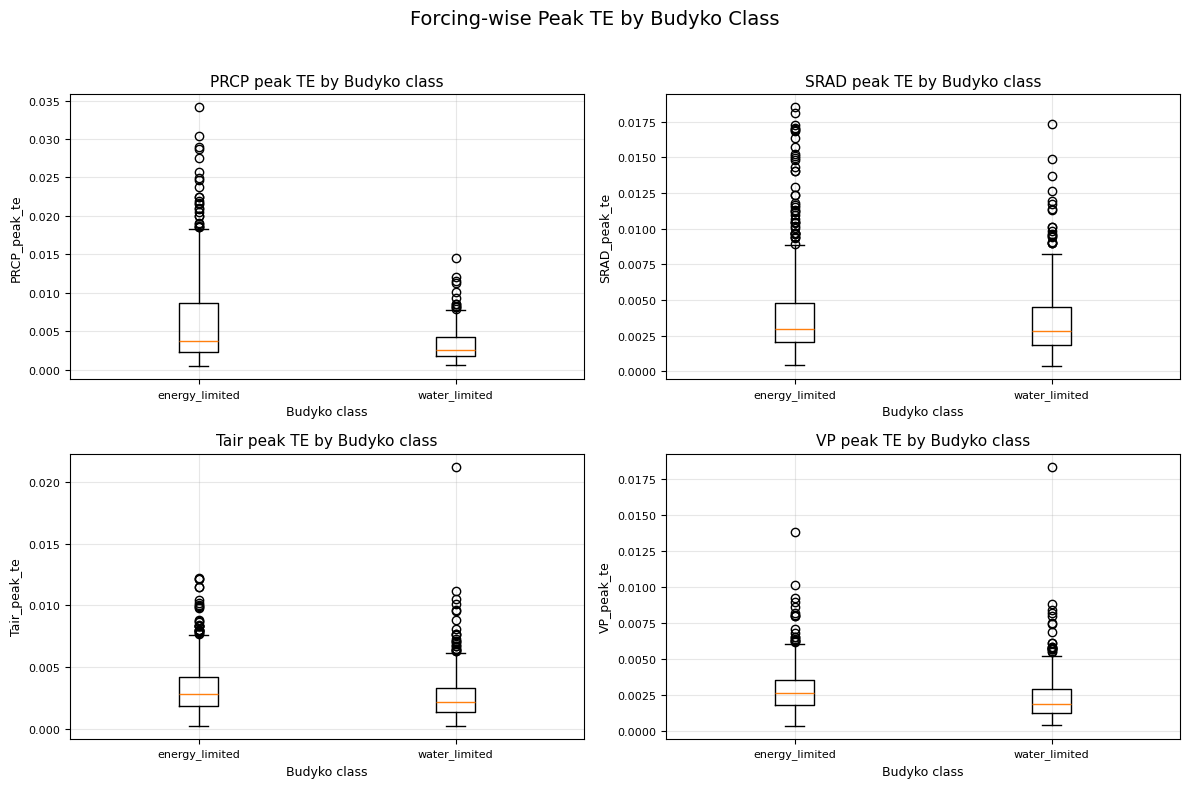

In [153]:
# Forcing-wise peak TE columns
peak_te_cols = ["PRCP_peak_te", "SRAD_peak_te", "Tair_peak_te", "VP_peak_te"]

# Summary table
budyko_te_rows = []

for te_col in peak_te_cols:
    forcing = te_col.replace("_peak_te", "")
    
    stats_df = (
        budyko_df.groupby("budyko_class")[te_col]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    stats_df["forcing"] = forcing
    stats_df["te_column"] = te_col
    budyko_te_rows.append(stats_df)

budyko_te_summary = pd.concat(budyko_te_rows, ignore_index=True)

# Save
budyko_te_file = OUT_SUMMARY / "peak_te_by_budyko_class_671basins.csv"
budyko_te_summary.to_csv(budyko_te_file, index=False)

print(budyko_te_file)
display(budyko_te_summary)

# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, te_col in zip(axes, peak_te_cols):
    forcing = te_col.replace("_peak_te", "")
    data = [
        budyko_df.loc[budyko_df["budyko_class"] == "energy_limited", te_col].dropna(),
        budyko_df.loc[budyko_df["budyko_class"] == "water_limited", te_col].dropna()
    ]
    
    ax.boxplot(data, tick_labels=["energy_limited", "water_limited"])
    ax.set_title(f"{forcing} peak TE by Budyko class", fontsize=11)
    ax.set_xlabel("Budyko class", fontsize=9)
    ax.set_ylabel(te_col, fontsize=9)
    ax.tick_params(axis="x", labelrotation=0, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Forcing-wise Peak TE by Budyko Class", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

These results show that all four forcings have higher average and median peak TE in energy-limited basins than in water-limited basins. The difference is strongest for PRCP, where both the center and spread are clearly larger in energy-limited basins. SRAD, Tair, and VP also show the same overall pattern, but the separation is more moderate. This suggests that, in our dataset, wetter or less arid basins tend to transmit stronger forcing-to-streamflow information, while drier basins have weaker peak TE overall. In simple terms, the strength of the forcing–streamflow connection is generally higher in energy-limited basins.

## Compare forcing-wise peak lag by Budyko class

In this step, I compare the peak lag of PRCP, SRAD, Tair, and VP between energy-limited and water-limited basins using boxplots and save a summary CSV.

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv\peak_lag_by_budyko_class_671basins.csv


,budyko_class,count,mean,median,std,forcing,lag_column
0,energy_limited,436,1.662844,1.0,2.908346,PRCP,PRCP_peak_lag
1,water_limited,235,4.059574,1.0,6.952576,PRCP,PRCP_peak_lag
2,energy_limited,436,6.190367,1.0,8.728234,SRAD,SRAD_peak_lag
3,water_limited,235,7.289362,2.0,9.239067,SRAD,SRAD_peak_lag
4,energy_limited,436,14.878440,13.5,9.744855,Tair,Tair_peak_lag
5,water_limited,235,12.055319,8.0,10.116476,Tair,Tair_peak_lag
6,energy_limited,436,12.791284,11.0,10.232246,VP,VP_peak_lag
7,water_limited,235,8.570213,4.0,9.198103,VP,VP_peak_lag


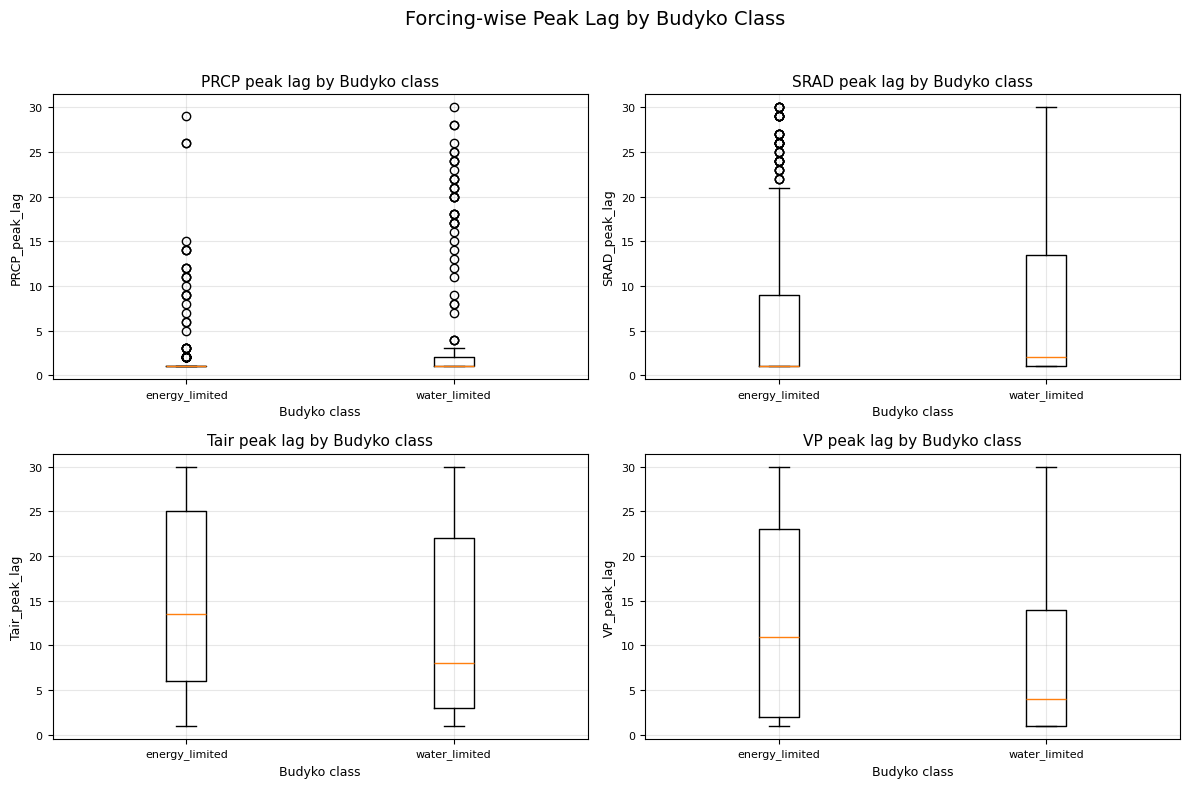

In [154]:
# Forcing-wise peak lag columns
peak_lag_cols = ["PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag"]

# Summary table
budyko_lag_rows = []

for lag_col in peak_lag_cols:
    forcing = lag_col.replace("_peak_lag", "")
    
    stats_df = (
        budyko_df.groupby("budyko_class")[lag_col]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    stats_df["forcing"] = forcing
    stats_df["lag_column"] = lag_col
    budyko_lag_rows.append(stats_df)

budyko_lag_summary = pd.concat(budyko_lag_rows, ignore_index=True)

# Save
budyko_lag_file = OUT_SUMMARY / "peak_lag_by_budyko_class_671basins.csv"
budyko_lag_summary.to_csv(budyko_lag_file, index=False)

print(budyko_lag_file)
display(budyko_lag_summary)

# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, lag_col in zip(axes, peak_lag_cols):
    forcing = lag_col.replace("_peak_lag", "")
    data = [
        budyko_df.loc[budyko_df["budyko_class"] == "energy_limited", lag_col].dropna(),
        budyko_df.loc[budyko_df["budyko_class"] == "water_limited", lag_col].dropna()
    ]
    
    ax.boxplot(data, tick_labels=["energy_limited", "water_limited"])
    ax.set_title(f"{forcing} peak lag by Budyko class", fontsize=11)
    ax.set_xlabel("Budyko class", fontsize=9)
    ax.set_ylabel(lag_col, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Forcing-wise Peak Lag by Budyko Class", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

These results show that Budyko class affects lag differently for different forcings. For PRCP and SRAD, the water-limited basins have somewhat longer response timing overall, although the median lag is still short, especially for PRCP. In contrast, for Tair and VP, the energy-limited basins have clearly longer peak lags, with much higher medians than the water-limited group. This suggests that in wetter, energy-limited basins, temperature- and vapor-related controls act over a longer delayed timescale, likely because of storage, snow influence, and slower seasonal response. Overall, the Budyko refactor now shows both strength differences and timing differences between hydroclimatic regimes.

## Plot CONUS maps with state borders and state names

In this step, I plot forcing-wise peak TE on a CONUS basemap with coastlines, country borders, state boundaries, and small state-name labels. The figure is shown in notebook output and also saved as a PDF.

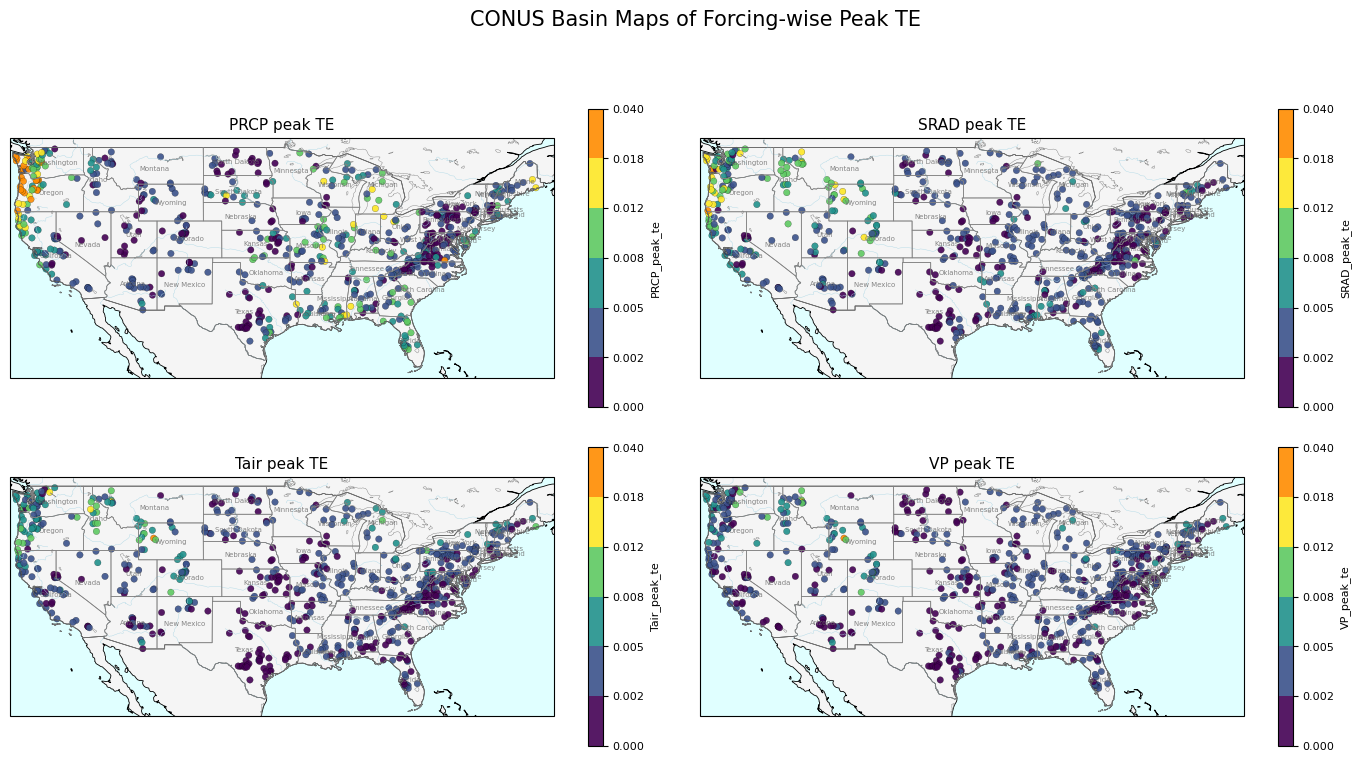

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\pdf\conus_maps_peak_te_four_forcings_with_states_classified.pdf


In [155]:
# Use one row per basin
map_df = budyko_df.drop_duplicates(subset="gauge_id").copy()

# Fix longitude if stored as positive west values
map_df["gauge_lon_plot"] = map_df["gauge_lon"].copy()
if map_df["gauge_lon_plot"].mean() > 0:
    map_df["gauge_lon_plot"] = -map_df["gauge_lon_plot"]

# Forcing-wise peak TE columns
map_te_cols = ["PRCP_peak_te", "SRAD_peak_te", "Tair_peak_te", "VP_peak_te"]

# Output file
conus_te_pdf = OUT_PDF / "conus_maps_peak_te_four_forcings_with_states_classified.pdf"

# Read US states shapefile from Natural Earth
states_shp = shpreader.natural_earth(
    resolution="50m",
    category="cultural",
    name="admin_1_states_provinces"
)
states_reader = shpreader.Reader(states_shp)
state_records = list(states_reader.records())

# Keep only CONUS states
exclude_names = {
    "Alaska", "Hawaii", "Puerto Rico",
    "American Samoa", "Guam", "Northern Mariana Islands",
    "United States Virgin Islands", "District of Columbia"
}

conus_states = []
for rec in state_records:
    attrs = rec.attributes
    admin = attrs.get("admin")
    name = attrs.get("name")
    if admin == "United States of America" and name not in exclude_names:
        conus_states.append(rec)

# Fixed class boundaries for all maps
bounds = [0.0, 0.002, 0.005, 0.008, 0.012, 0.018, 0.04]

# Strongly separated discrete colors
cmap = ListedColormap([
    "#440154",  # very low
    "#3b528b",  # low
    "#21918c",  # moderate
    "#5ec962",  # moderately high
    "#fde725",  # high
    "#ff8c00"   # very high
])

norm = BoundaryNorm(bounds, cmap.N)

with PdfPages(conus_te_pdf) as pdf:
    fig, axes = plt.subplots(
        2, 2, figsize=(14, 8),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    axes = axes.flatten()

    for ax, te_col in zip(axes, map_te_cols):
        forcing = te_col.replace("_peak_te", "")

        # Map extent
        ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

        # Background features
        ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
        ax.add_feature(cfeature.OCEAN, facecolor="lightcyan")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.LAKES, edgecolor="gray", facecolor="none", linewidth=0.3)
        ax.add_feature(cfeature.RIVERS, edgecolor="lightblue", linewidth=0.3)

        # State borders
        for rec in conus_states:
            ax.add_geometries(
                [rec.geometry],
                crs=ccrs.PlateCarree(),
                facecolor="none",
                edgecolor="gray",
                linewidth=0.5
            )

        # State names
        for rec in conus_states:
            geom = rec.geometry
            pt = geom.representative_point()
            state_name = rec.attributes.get("name", "")
            ax.text(
                pt.x, pt.y, state_name,
                transform=ccrs.PlateCarree(),
                fontsize=5,
                color="dimgray",
                ha="center",
                va="center",
                alpha=0.8
            )

        # Basin points
        sc = ax.scatter(
            map_df["gauge_lon_plot"],
            map_df["gauge_lat"],
            c=map_df[te_col],
            cmap=cmap,
            norm=norm,
            s=22,
            edgecolors="black",
            linewidths=0.15,
            alpha=0.9,
            transform=ccrs.PlateCarree()
        )

        ax.set_title(f"{forcing} peak TE", fontsize=11)

        cbar = plt.colorbar(
            sc,
            ax=ax,
            shrink=0.82,
            boundaries=bounds,
            ticks=bounds
        )
        cbar.set_label(te_col, fontsize=8)
        cbar.ax.tick_params(labelsize=8)

    fig.suptitle("CONUS Basin Maps of Forcing-wise Peak TE", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    pdf.savefig(fig, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(conus_te_pdf)

These CONUS maps show the spatial distribution of forcing-wise peak TE for all 671 CAMELS basins, using a common color scale across all four panels, so the colors can be compared directly. PRCP peak TE shows the strongest and most widespread high values, especially in parts of the western U.S. and some humid basins in the east, confirming that precipitation is the main direct driver of streamflow information transfer in many basins. SRAD peak TE is generally weaker than PRCP, but still shows noticeable high values in several western and northwestern basins, indicating an important secondary role of energy-related controls. Tair peak TE and VP peak TE are usually lower overall, with fewer high-value basins, but they still show clear spatial structure rather than random noise, meaning temperature and vapor pressure also contribute meaningfully in some regions. Overall, these maps suggest that the strength of forcing–streamflow information transfer varies strongly across the U.S., with PRCP being the strongest overall, while SRAD, Tair, and VP provide more moderate and regionally dependent influence.

## Plot CONUS maps for only dominant basins of each forcing

In this step, I plot only the basins where each forcing is the dominant forcing. Each panel shows the dominant basins for one forcing, colored by that forcing’s peak TE. The figure is shown in notebook output and also saved as a PDF.

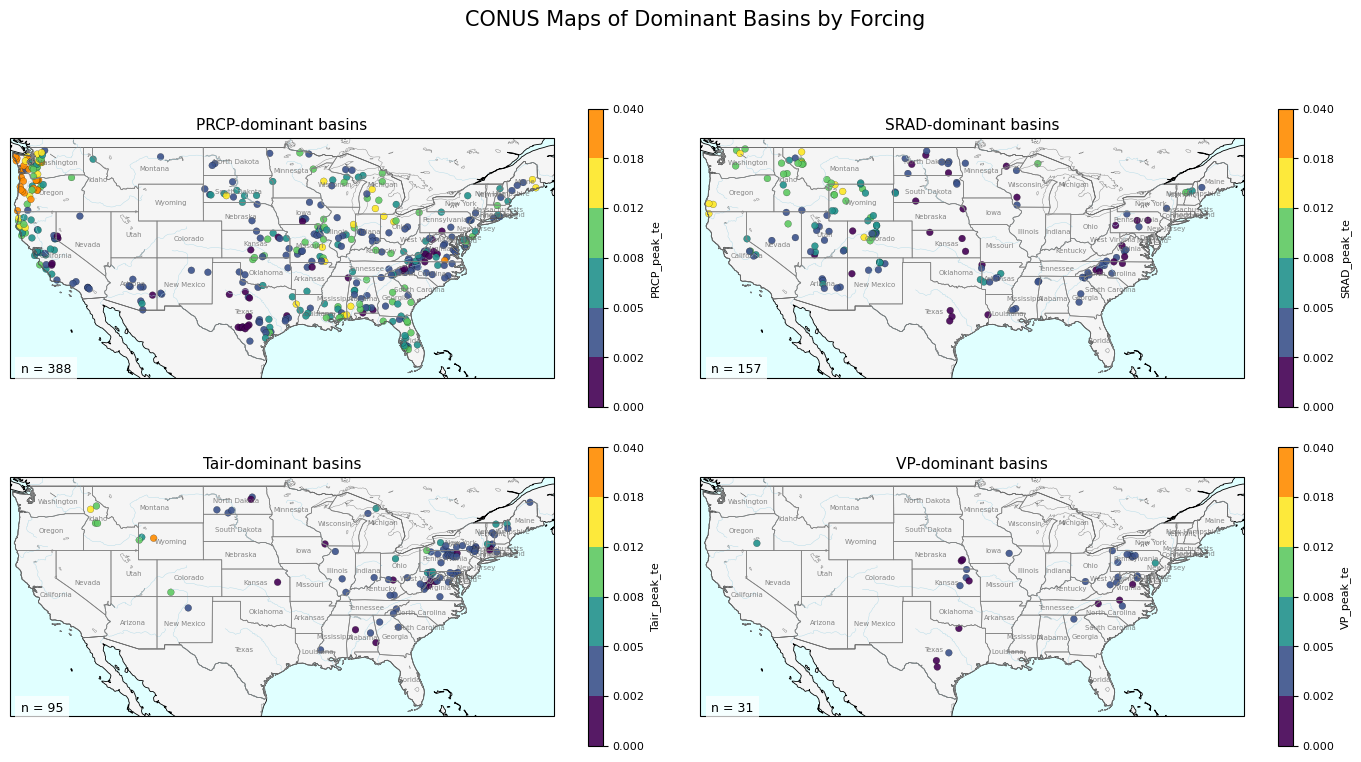

c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\pdf\conus_maps_dominant_basins_by_forcing_classified.pdf


In [156]:
# Use one row per basin
dom_map_df = budyko_df.drop_duplicates(subset="gauge_id").copy()

# Fix longitude if stored as positive west values
dom_map_df["gauge_lon_plot"] = dom_map_df["gauge_lon"].copy()
if dom_map_df["gauge_lon_plot"].mean() > 0:
    dom_map_df["gauge_lon_plot"] = -dom_map_df["gauge_lon_plot"]

# Forcing list
forcings = ["PRCP", "SRAD", "Tair", "VP"]

# Output file
dominant_conus_pdf = OUT_PDF / "conus_maps_dominant_basins_by_forcing_classified.pdf"

# Read US states shapefile
states_shp = shpreader.natural_earth(
    resolution="50m",
    category="cultural",
    name="admin_1_states_provinces"
)
states_reader = shpreader.Reader(states_shp)
state_records = list(states_reader.records())

exclude_names = {
    "Alaska", "Hawaii", "Puerto Rico",
    "American Samoa", "Guam", "Northern Mariana Islands",
    "United States Virgin Islands", "District of Columbia"
}

conus_states = []
for rec in state_records:
    attrs = rec.attributes
    admin = attrs.get("admin")
    name = attrs.get("name")
    if admin == "United States of America" and name not in exclude_names:
        conus_states.append(rec)

# Fixed class boundaries for all four panels
bounds = [0.0, 0.002, 0.005, 0.008, 0.012, 0.018, 0.04]

# Strongly separated discrete colors
cmap = ListedColormap([
    "#440154",  # very low
    "#3b528b",  # low
    "#21918c",  # moderate
    "#5ec962",  # moderately high
    "#fde725",  # high
    "#ff8c00"   # very high
])

norm = BoundaryNorm(bounds, cmap.N)

with PdfPages(dominant_conus_pdf) as pdf:
    fig, axes = plt.subplots(
        2, 2, figsize=(14, 8),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    axes = axes.flatten()

    for ax, forcing in zip(axes, forcings):
        te_col = f"{forcing}_peak_te"
        sub = dom_map_df[dom_map_df["dominant_forcing"] == forcing].copy()

        # Map extent
        ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

        # Background
        ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
        ax.add_feature(cfeature.OCEAN, facecolor="lightcyan")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.LAKES, edgecolor="gray", facecolor="none", linewidth=0.3)
        ax.add_feature(cfeature.RIVERS, edgecolor="lightblue", linewidth=0.3)

        # State borders
        for rec in conus_states:
            ax.add_geometries(
                [rec.geometry],
                crs=ccrs.PlateCarree(),
                facecolor="none",
                edgecolor="gray",
                linewidth=0.5
            )

        # State names
        for rec in conus_states:
            geom = rec.geometry
            pt = geom.representative_point()
            state_name = rec.attributes.get("name", "")
            ax.text(
                pt.x, pt.y, state_name,
                transform=ccrs.PlateCarree(),
                fontsize=5,
                color="dimgray",
                ha="center",
                va="center",
                alpha=0.8
            )

        # Plot only dominant basins for this forcing
        sc = ax.scatter(
            sub["gauge_lon_plot"],
            sub["gauge_lat"],
            c=sub[te_col],
            cmap=cmap,
            norm=norm,
            s=24,
            edgecolors="black",
            linewidths=0.15,
            alpha=0.9,
            transform=ccrs.PlateCarree()
        )

        ax.set_title(f"{forcing}-dominant basins", fontsize=11)

        cbar = plt.colorbar(
            sc,
            ax=ax,
            shrink=0.82,
            boundaries=bounds,
            ticks=bounds
        )
        cbar.set_label(te_col, fontsize=8)
        cbar.ax.tick_params(labelsize=8)

        # Small text count
        ax.text(
            0.02, 0.02,
            f"n = {len(sub)}",
            transform=ax.transAxes,
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

    fig.suptitle("CONUS Maps of Dominant Basins by Forcing", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    pdf.savefig(fig, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(dominant_conus_pdf)

These maps show where each forcing is the dominant one, meaning the forcing with the highest peak TE for that basin. The pattern is very clear. PRCP-dominant basins are by far the most common and are distributed across much of the U.S., confirming that precipitation is the main control on streamflow information transfer in most basins. SRAD-dominant basins are fewer and appear more selectively, especially in parts of the West and some eastern basins, showing that solar-radiation effects become dominant only in certain hydroclimatic settings. Tair-dominant basins are even fewer and are concentrated in more specific regions, suggesting that temperature becomes the strongest control mainly where delayed seasonal or snow-related processes matter. VP-dominant basins are the rarest, with only a small number of scattered locations, so vapor pressure is usually not the strongest forcing compared with the other three. Overall, these maps show that precipitation dominates most basins, while SRAD, Tair, and VP dominate only in smaller, more region-specific groups of basins.

## Plot CONUS maps for all numeric CAMELS attributes

In this step, I plot all numeric CAMELS attributes on CONUS maps and save them as a multi-page PDF. Each page contains 6 attribute maps.

In [157]:
# One row per basin
attr_map_df = te_attr_peak_df.drop_duplicates(subset="gauge_id").copy()

# Fix longitude if needed
attr_map_df["gauge_lon_plot"] = attr_map_df["gauge_lon"].copy()
if attr_map_df["gauge_lon_plot"].mean() > 0:
    attr_map_df["gauge_lon_plot"] = -attr_map_df["gauge_lon_plot"]

# If numeric_attr_cols is not already available, rebuild it
exclude_cols = {
    "gauge_id", "huc_02",
    "peak_lag", "peak_TE",
    "PRCP", "SRAD", "Tair", "VP",
    "PRCP_peak_te", "SRAD_peak_te", "Tair_peak_te", "VP_peak_te",
    "PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag",
    "gauge_lon_plot", "gauge_lat", "gauge_lon"
}

all_numeric_cols = attr_map_df.select_dtypes(include="number").columns.tolist()
numeric_attr_cols = [c for c in all_numeric_cols if c not in exclude_cols]

print("Total numeric attributes to map:", len(numeric_attr_cols))

# Output file
all_attr_map_pdf = OUT_PDF / "conus_maps_all_numeric_attributes_classified.pdf"

# Read US states shapefile
states_shp = shpreader.natural_earth(
    resolution="50m",
    category="cultural",
    name="admin_1_states_provinces"
)
states_reader = shpreader.Reader(states_shp)
state_records = list(states_reader.records())

exclude_names = {
    "Alaska", "Hawaii", "Puerto Rico",
    "American Samoa", "Guam", "Northern Mariana Islands",
    "United States Virgin Islands", "District of Columbia"
}

conus_states = []
for rec in state_records:
    attrs = rec.attributes
    admin = attrs.get("admin")
    name = attrs.get("name")
    if admin == "United States of America" and name not in exclude_names:
        conus_states.append(rec)

# set True only if we want every page shown in notebook output
SHOW_IN_NOTEBOOK = False

maps_per_page = 6
n_pages = math.ceil(len(numeric_attr_cols) / maps_per_page)

# Strong discrete colors
cmap = ListedColormap([
    "#440154",
    "#3b528b",
    "#21918c",
    "#5ec962",
    "#bddf26",
    "#fde725"
])

with PdfPages(all_attr_map_pdf) as pdf:
    for page in range(n_pages):
        start = page * maps_per_page
        end = min(start + maps_per_page, len(numeric_attr_cols))
        page_attrs = numeric_attr_cols[start:end]

        fig, axes = plt.subplots(
            2, 3, figsize=(16, 8),
            subplot_kw={"projection": ccrs.PlateCarree()}
        )
        axes = axes.flatten()

        for ax, attr in zip(axes, page_attrs):
            ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

            ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
            ax.add_feature(cfeature.OCEAN, facecolor="lightcyan")
            ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
            ax.add_feature(cfeature.BORDERS, linewidth=0.5)
            ax.add_feature(cfeature.LAKES, edgecolor="gray", facecolor="none", linewidth=0.3)
            ax.add_feature(cfeature.RIVERS, edgecolor="lightblue", linewidth=0.3)

            for rec in conus_states:
                ax.add_geometries(
                    [rec.geometry],
                    crs=ccrs.PlateCarree(),
                    facecolor="none",
                    edgecolor="gray",
                    linewidth=0.4
                )

            vals = attr_map_df[attr].dropna()

            # Build 6 quantile classes for this attribute
            if vals.nunique() > 1:
                bounds = np.quantile(vals, [0.0, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0])
                bounds = np.unique(bounds)

                if len(bounds) < 3:
                    bounds = np.linspace(vals.min(), vals.max(), 7)
            else:
                bounds = np.array([vals.min(), vals.max() + 1e-12])

            norm = BoundaryNorm(bounds, cmap.N, clip=True)

            sc = ax.scatter(
                attr_map_df["gauge_lon_plot"],
                attr_map_df["gauge_lat"],
                c=attr_map_df[attr],
                cmap=cmap,
                norm=norm,
                s=20,
                edgecolors="black",
                linewidths=0.15,
                alpha=0.9,
                transform=ccrs.PlateCarree()
            )

            ax.set_title(attr, fontsize=10)

            cbar = plt.colorbar(
                sc,
                ax=ax,
                shrink=0.82,
                boundaries=bounds,
                ticks=bounds
            )
            cbar.set_label(attr, fontsize=8)
            cbar.ax.tick_params(labelsize=7)

        # Hide any unused subplot on the last page
        for j in range(len(page_attrs), len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(
            f"CONUS Maps of Numeric CAMELS Attributes (Page {page+1} of {n_pages})",
            fontsize=14
        )
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        pdf.savefig(fig, bbox_inches="tight")

        if SHOW_IN_NOTEBOOK:
            plt.show()

        plt.close(fig)

print(all_attr_map_pdf)

Total numeric attributes to map: 50
c:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\pdf\conus_maps_all_numeric_attributes_classified.pdf
